# Kampala Air Quality and TB Analysis - Full Dataset Pipeline


# Step 1: Load and Process Data


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import geopandas as gpd
from datetime import date
from pathlib import Path
from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Concatenate
from tensorflow.keras.callbacks import EarlyStopping

import sys
sys.path.append('./src')

from simplified_data_processor import SimplifiedDataProcessor
from intervention_simulator import InterventionSimulator
from time_series_modeler import TimeSeriesModeler
from visualizer import Visualizer
from report_generator import ReportGenerator

# Set up plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All modules imported successfully")

import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')


✓ All modules imported successfully


In [2]:
resp_df = pd.read_excel('data/Data RTI DHIS2.xls', sheet_name='MOH - Uganda, Kampala', header=2)
clim_df = pd.read_csv('data/epi_weekly_climate data_kampala.csv')
plo_df = pd.read_csv('data/kampala_weekly_PM2.5 climate data averaged_across_sites.csv')

main_df = pd.merge(
    clim_df,
    plo_df,
    left_on=['epi_year', 'epi_week'],
    right_on=['year', 'week'],
    how='inner'
)

drop_cols = ['year', 'week']
main_df.drop(columns=drop_cols, inplace=True)

# Function to get the last day (Sunday) of each ISO week
def get_last_day_of_week(year, week):
    return date.fromisocalendar(int(year), int(week), 7)

# Apply function to create a proper date column
main_df['date'] = main_df.apply(
    lambda row: get_last_day_of_week(row['epi_year'], row['epi_week']),
    axis=1
)

main_df['date'] = pd.to_datetime(main_df['date'])   # ensure datetime dtype

# Extract the last date (Sunday) from periodname
resp_df['date'] = resp_df['periodname'].str.extract(r'-\s*(\d{4}-\d{2}-\d{2})')
resp_df['date'] = pd.to_datetime(resp_df['date'], errors='coerce')

# Keep all respiratory disease columns
resp_df = resp_df.drop(columns=['periodname'])  # drop only the text period column


In [3]:
# --- Merge climate and respiratory disease indicators ---
# Exclude death outcomes before combining the source data.
resp_df = resp_df.drop(columns=['ILD deaths', 'SARI Deaths', 'Severe pneumonia under 5 deaths'], errors='ignore')
merged_df = pd.merge(main_df, resp_df, on='date', how='inner')


# Rename climate columns to match processor expectations
rename_map = {
    'weekly_pm25_avg': 'pm2_5',
    'weekly_temp_avg': 'avgtemp',
    'weekly_humidity_avg': 'avghumidity',
    'Pulmonary TB cases': 'TB',
    'Avg_Temp(C)': 'avgtemp_sat',
    'AvgWindspeed(m/s)': 'windspeed',
    'AvgPrecipitation(mm/day)': 'precip',
    'AvgRelative_Humidity(%)': 'humidity_sat',
    'ILI Cases': 'ILI',
    'Severe pneumonia under 5 Cases': 'pneumonia_u5',
    'SARI Cases': 'SARI',
}

merged_df.rename(columns=rename_map, inplace=True)


In [4]:
# Select the columns you want to impute
disease_columns = [col for col in ['TB', 'ILI', 'pneumonia_u5', 'SARI'] if col in merged_df.columns]
cols_to_impute = [col for col in ['pm2_5', 'avgtemp', 'avghumidity', *disease_columns] if col in merged_df.columns]

imputer = SimpleImputer(strategy='mean')  # or 'median', 'most_frequent'
merged_df[cols_to_impute] = imputer.fit_transform(merged_df[cols_to_impute])

# Save merged dataset
merged_df.to_csv('data/merged_climate_respiratory_data.csv', index=False)


In [5]:
# ## Step 1: Load and Process Data

# %%
# Initialize data processor
processor = SimplifiedDataProcessor(data_dir='../data')

# Load the merged data
data = processor.load_data('./data/merged_climate_respiratory_data.csv')
print(f"✓ Loaded data: {len(data)} records")


INFO:simplified_data_processor:SimplifiedDataProcessor initialized with data directory: ..\data
INFO:simplified_data_processor:Loading data from ./data/merged_climate_respiratory_data.csv
INFO:simplified_data_processor:Loaded 248 records
INFO:simplified_data_processor:Data processing complete: 248 records


✓ Loaded data: 248 records


In [ ]:
# Add disease-neutral and disease-specific lag features
processed_data = processor.add_lag_features()
processed_data['date'] = pd.to_datetime(processed_data['date'], errors='coerce', dayfirst=True)
disease_columns = [col for col in ['TB', 'ILI', 'pneumonia_u5', 'SARI'] if col in processed_data.columns]
processed_data['temp_humidity_interaction'] = processed_data['avgtemp'] * processed_data['avghumidity']
processed_data['precip_rolling_4'] = processed_data['precip'].rolling(window=4, min_periods=1).mean()
processed_data['windspeed_rolling_4'] = processed_data['windspeed'].rolling(window=4, min_periods=1).mean()
for window in [7, 14, 30]:
    processed_data[f'pm25_trailing_ma_{window}'] = processed_data['pm2_5'].rolling(window=window, min_periods=1).mean()
    for disease in disease_columns:
        processed_data[f'{disease}_trailing_ma_{window}'] = processed_data[disease].rolling(window=window, min_periods=1).mean()
for disease in disease_columns:
    processed_data[f'{disease}_pct_change_1'] = processed_data[disease].pct_change().replace([np.inf, -np.inf], np.nan)
    processed_data[f'{disease}_diff_1'] = processed_data[disease].diff()
processed_data['pm25_temp_ratio'] = processed_data['pm2_5'] / (processed_data['avgtemp'].abs() + 1)
processed_data['pm25_humidity_ratio'] = processed_data['pm2_5'] / (processed_data['avghumidity'].abs() + 1)
print(f'Added features for {len(disease_columns)} disease outcomes: {", ".join(disease_columns)}')


In [7]:
# Summary statistics for every disease
summary = processor.get_summary_statistics()
disease_columns = [col for col in ['TB', 'ILI', 'pneumonia_u5', 'SARI'] if col in processed_data.columns]
disease_summary = processed_data[disease_columns].agg(['count', 'sum', 'mean']).T.rename(columns={'sum': 'Total cases', 'mean': 'Mean cases'})
print(f"Date range: {summary['date_range']}")
print(f"Average PM2.5: {summary['pm25_statistics']['mean']:.2f} μg/m³")
display(disease_summary)


Date range: 2020-01-05 00:00:00 to 2024-12-15 00:00:00
Average PM2.5: 39.28 μg/m³


,count,Total cases,Mean cases
TB,248.0,158287.771429,638.257143
ILI,248.0,84307.803279,339.950820
pneumonia_u5,248.0,30780.000000,124.112903
SARI,248.0,54591.000000,220.125000


In [8]:
# Display first few rows including diseases and engineered features
disease_cols = [
    col for col in ['TB', 'ILI', 'pneumonia_u5', 'SARI']
    if col in processed_data.columns
]
preview_cols = [
    'date', 'pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip'
] + disease_cols + [
    'precip_rolling_4', 'windspeed_rolling_4', 'pm25_temp_ratio',
    'pm25_humidity_ratio'
]
preview_cols = [col for col in preview_cols if col in processed_data.columns]
processed_data[preview_cols].head(10)


,date,pm2_5,avgtemp,avghumidity,windspeed,precip,TB,ILI,pneumonia_u5,SARI,precip_rolling_4,windspeed_rolling_4,pm25_temp_ratio,pm25_humidity_ratio
0,2020-01-05,43.77,24.45,72.79,2.08,2.52,7.0,339.95082,16.0,1.0,2.520000,2.080000,1.719843,0.593170
1,2020-01-12,68.62,23.01,75.92,2.69,12.99,30.0,339.95082,15.0,44.0,7.755000,2.385000,2.857976,0.892096
2,2020-01-19,72.99,24.49,70.07,2.18,14.48,40.0,339.95082,4.0,11.0,9.996667,2.316667,2.863476,1.027016
3,2020-01-26,90.92,24.11,54.71,3.01,5.51,37.0,339.95082,16.0,79.0,8.875000,2.490000,3.620868,1.632023
4,2020-02-02,35.29,21.79,83.86,1.91,66.83,343.0,37.00000,39.0,102.0,24.952500,2.447500,1.548486,0.415861
5,2020-02-09,44.04,22.47,81.82,2.00,86.25,173.0,14.00000,38.0,131.0,43.267500,2.275000,1.876438,0.531756
6,2020-02-16,61.22,24.49,68.12,2.42,1.91,302.0,32.00000,85.0,198.0,40.125000,2.335000,2.401726,0.885706
7,2020-02-23,40.34,24.66,76.43,2.08,15.50,265.0,52.00000,78.0,167.0,42.622500,2.102500,1.572097,0.520987
8,2020-03-01,45.60,24.15,78.90,1.91,24.74,340.0,47.00000,112.0,254.0,32.100000,2.102500,1.813121,0.570713
9,2020-03-08,47.95,23.45,83.80,2.19,34.51,338.0,7.00000,125.0,258.0,19.165000,2.150000,1.961145,0.565448


## 1. Descriptive results

The table below is the first results output. It documents the analytical sample, distribution of PM₂.₅ and meteorology, and reported health outcomes before model-based estimates are interpreted.


In [9]:
# Table 1. Descriptive statistics for the analytic dataset
from IPython.display import display

descriptive_variables = [
    'pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip'
] + [c for c in disease_cols if c in processed_data.columns]
numeric_descriptive_data = processed_data[descriptive_variables].apply(pd.to_numeric, errors='coerce')

descriptive_table = (
    numeric_descriptive_data
    .agg(['count', 'mean', 'std', 'min', 'median', 'max'])
    .T
    .rename(columns={
        'count': 'Observed periods', 'mean': 'Mean per period', 'std': 'SD',
        'min': 'Minimum', 'median': 'Median', 'max': 'Maximum'
    })
)
descriptive_table['Total cases'] = np.nan
descriptive_table.loc[disease_cols, 'Total cases'] = numeric_descriptive_data[disease_cols].sum(min_count=1)
descriptive_table.index.name = 'Variable'
descriptive_table = descriptive_table.round(2)

missingness_table = processed_data[descriptive_variables].isna().sum().rename('Missing periods').to_frame()
missingness_table['Missing %'] = (100 * missingness_table['Missing periods'] / len(processed_data)).round(1)

print(f"Analytic period: {processed_data['date'].min():%Y-%m-%d} to {processed_data['date'].max():%Y-%m-%d}")
print(f"Analytic observations: {len(processed_data):,}")
print('Disease totals are sums across observed reporting periods; environmental variables intentionally have no total.')
display(descriptive_table)
print('Missingness before model-specific handling:')
display(missingness_table)


Analytic period: 2020-01-05 to 2024-12-15
Analytic observations: 248
Disease totals are sums across observed reporting periods; environmental variables intentionally have no total.


,Observed periods,Mean per period,SD,Minimum,Median,Maximum,Total cases
Variable,,,,,,,
pm2_5,248.0,39.28,11.81,16.87,38.06,90.92,NaN
avgtemp,248.0,22.85,0.97,20.83,22.72,27.04,NaN
avghumidity,248.0,80.96,5.05,54.71,81.60,90.06,NaN
windspeed,248.0,2.45,0.61,1.61,2.27,4.68,NaN
precip,248.0,28.21,27.76,0.02,19.16,133.74,NaN
TB,248.0,638.26,251.80,7.00,638.26,1321.00,158287.77
ILI,248.0,339.95,718.62,1.00,40.50,3498.00,84307.80
pneumonia_u5,248.0,124.11,75.61,4.00,116.00,1037.00,30780.00
SARI,248.0,220.12,161.49,1.00,172.50,1375.00,54591.00


Missingness before model-specific handling:


,Missing periods,Missing %
pm2_5,0,0.0
avgtemp,0,0.0
avghumidity,0,0.0
windspeed,0,0.0
precip,0,0.0
TB,0,0.0
ILI,0,0.0
pneumonia_u5,0,0.0
SARI,0,0.0


### 2. Main regression estimates

Adjusted Poisson models estimate the association between a 10 µg/m³ higher PM₂.₅ concentration and reported outcomes, controlling for temperature, humidity, precipitation, long-term time trend, and calendar month. Incidence-rate ratios (IRRs) are reported with 95% confidence intervals. These estimates describe associations and should not be interpreted as causal effects.


In [10]:
# Main adjusted Poisson regression estimates (per 10 µg/m³ PM2.5)
import statsmodels.api as sm

def poisson_pm25_model(frame, outcome, additional_terms=None):
    terms = ['pm2_5', 'avgtemp', 'avghumidity', 'precip', 'month']
    if additional_terms:
        terms += additional_terms
    model_data = frame[[outcome] + terms].apply(pd.to_numeric, errors='coerce').dropna().copy()
    model_data['time'] = np.arange(len(model_data))
    terms = terms + ['time']
    model_data = model_data[model_data[outcome] >= 0].copy()
    if len(model_data) < len(terms) + 10 or model_data[outcome].sum() == 0:
        return None
    X = sm.add_constant(model_data[terms], has_constant='add')
    fit = sm.GLM(model_data[outcome], X, family=sm.families.Poisson()).fit(cov_type='HC3')
    beta, se = fit.params['pm2_5'] * 10, fit.bse['pm2_5'] * 10
    return {
        'Outcome': outcome, 'N': int(fit.nobs),
        'IRR per 10 µg/m³': np.exp(beta),
        '95% CI lower': np.exp(beta - 1.96 * se),
        '95% CI upper': np.exp(beta + 1.96 * se),
        'p-value': fit.pvalues['pm2_5'], 'AIC': fit.aic
    }

regression_results = [poisson_pm25_model(processed_data, outcome) for outcome in disease_cols]
regression_results = pd.DataFrame([r for r in regression_results if r is not None])
if regression_results.empty:
    print('No outcome had sufficient non-missing observations for the adjusted Poisson model.')
else:
    display(regression_results.round({'IRR per 10 µg/m³': 3, '95% CI lower': 3, '95% CI upper': 3, 'p-value': 4, 'AIC': 1}))


,Outcome,N,IRR per 10 µg/m³,95% CI lower,95% CI upper,p-value,AIC
0,TB,248,0.952,0.924,0.981,0.0013,9616.2
1,ILI,248,1.173,1.030,1.335,0.0160,85163.4
2,pneumonia_u5,248,0.956,0.908,1.005,0.0803,7043.4
3,SARI,248,1.038,0.950,1.135,0.4100,20987.4


### 3. PM₂.₅ exposure–response relationships for all diseases

The exposure–response plot compares adjusted disease-specific rate ratios across the observed PM₂.₅ range, using the median PM₂.₅ concentration as the reference. It is intended to reveal departures from a simple linear exposure assumption.


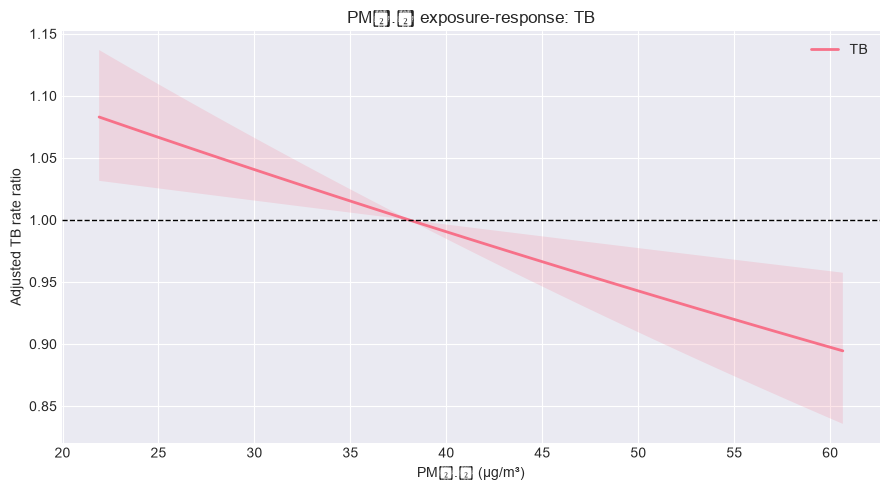

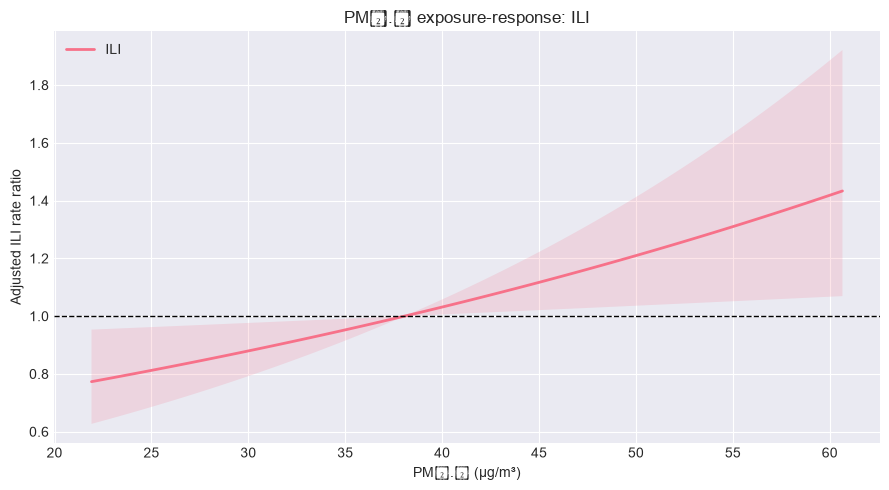

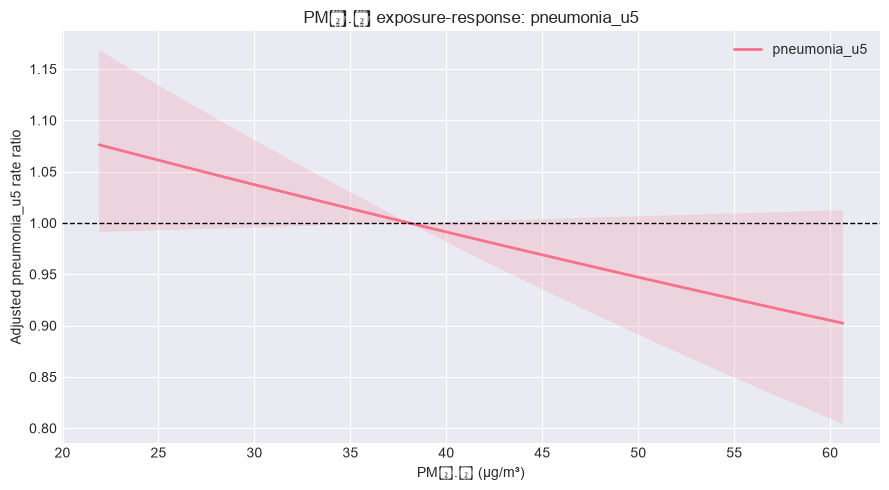

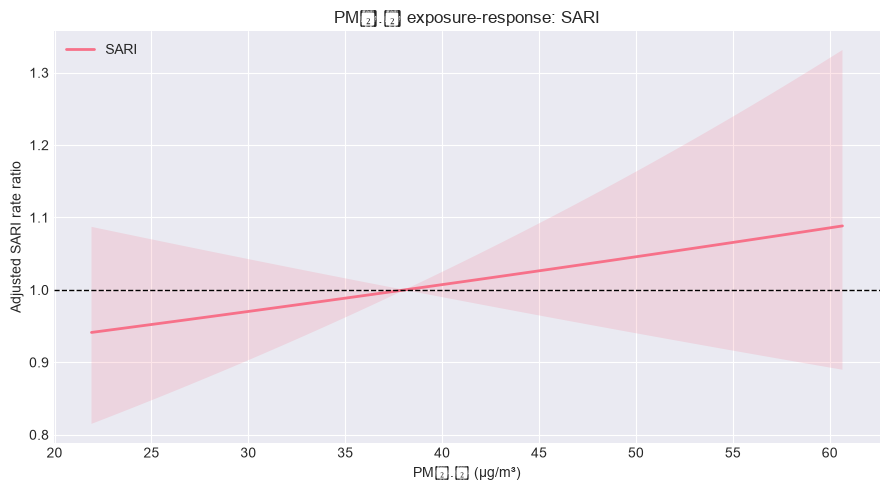

,Disease,Reference PM2.5,IRR per 10 µg/m³,95% CI lower,95% CI upper
0,TB,38.06,0.952,0.924,0.981
1,ILI,38.06,1.173,1.030,1.335
2,pneumonia_u5,38.06,0.956,0.908,1.005
3,SARI,38.06,1.038,0.950,1.135


In [11]:
# PM2.5 exposure-response relationships for every disease
exposure_terms = ['pm2_5', 'avgtemp', 'avghumidity', 'precip', 'month']
exposure_response_results = []
for disease in disease_columns:
    frame = processed_data[[disease] + exposure_terms].apply(pd.to_numeric, errors='coerce').dropna()
    frame = frame[frame[disease] >= 0].copy(); frame['time'] = np.arange(len(frame))
    terms = exposure_terms + ['time']
    if len(frame) < 20 or frame[disease].sum() <= 0: continue
    fit = sm.GLM(frame[disease], sm.add_constant(frame[terms], has_constant='add'), family=sm.families.Poisson()).fit(cov_type='HC3')
    grid = np.linspace(frame['pm2_5'].quantile(.05), frame['pm2_5'].quantile(.95), 100); reference = frame['pm2_5'].median()
    beta, se = fit.params['pm2_5'], fit.bse['pm2_5']
    fig, ax = plt.subplots(figsize=(9, 5)); log_rr = (grid-reference)*beta; se_log_rr = abs(grid-reference)*se
    ax.plot(grid, np.exp(log_rr), lw=2, label=disease); ax.fill_between(grid, np.exp(log_rr-1.96*se_log_rr), np.exp(log_rr+1.96*se_log_rr), alpha=.18)
    ax.axhline(1, color='black', ls='--', lw=1); ax.set(xlabel='PM₂.₅ (µg/m³)', ylabel=f'Adjusted {disease} rate ratio', title=f'PM₂.₅ exposure-response: {disease}'); ax.legend(); plt.tight_layout(); plt.show()
    exposure_response_results.append({'Disease': disease, 'Reference PM2.5': reference, 'IRR per 10 µg/m³': np.exp(beta*10), '95% CI lower': np.exp((beta-1.96*se)*10), '95% CI upper': np.exp((beta+1.96*se)*10)})
exposure_response_results = pd.DataFrame(exposure_response_results)
display(exposure_response_results.round(3))


### 4. DLNM lag-specific and cumulative effects

This distributed-lag Poisson model reports lag-specific and cumulative PM₂.₅ associations. The lag window is deliberately short and should be interpreted as an exploratory DLNM-style analysis; a full distributed-lag non-linear model would additionally require explicit exposure and lag basis functions selected a priori.


In [12]:
# Exploratory distributed-lag PM2.5 models for every disease
max_lag = 4; dlnm_rows = []; dlnm_cumulative_rows = []
for disease in disease_columns:
    frame = processed_data[[disease, 'pm2_5', 'avgtemp', 'avghumidity', 'precip', 'month']].copy(); frame['time'] = np.arange(len(frame))
    lag_terms = []
    for lag in range(max_lag + 1):
        name = f'pm25_lag_{lag}_dlnm'; frame[name] = pd.to_numeric(frame['pm2_5'], errors='coerce').shift(lag); lag_terms.append(name)
    terms = lag_terms + ['avgtemp', 'avghumidity', 'precip', 'time', 'month']; frame = frame[[disease] + terms].apply(pd.to_numeric, errors='coerce').dropna(); frame = frame[frame[disease] >= 0]
    if len(frame) < len(terms)+10 or frame[disease].sum() <= 0: continue
    fit = sm.GLM(frame[disease], sm.add_constant(frame[terms], has_constant='add'), family=sm.families.Poisson()).fit(cov_type='HC3')
    for lag in range(max_lag+1):
        term=f'pm25_lag_{lag}_dlnm'; beta=fit.params[term]*10; se=fit.bse[term]*10
        dlnm_rows.append({'Disease': disease, 'Lag': lag, 'IRR per 10 µg/m³': np.exp(beta), '95% CI lower': np.exp(beta-1.96*se), '95% CI upper': np.exp(beta+1.96*se)})
    beta = fit.params[lag_terms].sum()*10; cov=fit.cov_params().loc[lag_terms, lag_terms]; se=np.sqrt(cov.to_numpy().sum())*10
    dlnm_cumulative_rows.append({'Disease': disease, 'Lag window': f'0–{max_lag}', 'Cumulative IRR per 10 µg/m³': np.exp(beta), '95% CI lower': np.exp(beta-1.96*se), '95% CI upper': np.exp(beta+1.96*se)})
dlnm_results = pd.DataFrame(dlnm_rows); dlnm_cumulative = pd.DataFrame(dlnm_cumulative_rows)
display(dlnm_results.round(3)); display(dlnm_cumulative.round(3))


,Disease,Lag,IRR per 10 µg/m³,95% CI lower,95% CI upper
0,TB,0,0.965,0.934,0.997
1,TB,1,1.000,0.965,1.036
2,TB,2,1.010,0.979,1.042
3,TB,3,0.997,0.968,1.027
4,TB,4,1.006,0.980,1.033
5,ILI,0,1.034,0.877,1.219
6,ILI,1,1.066,0.856,1.328
7,ILI,2,0.961,0.792,1.164
8,ILI,3,1.035,0.851,1.260
9,ILI,4,1.087,0.904,1.308


,Disease,Lag window,Cumulative IRR per 10 µg/m³,95% CI lower,95% CI upper
0,TB,0–4,0.977,0.952,1.002
1,ILI,0–4,1.192,1.032,1.377
2,pneumonia_u5,0–4,0.969,0.903,1.039
3,SARI,0–4,1.043,0.951,1.144


### 5. Temperature and humidity effects

The adjusted model below reports associations of temperature (per 1 °C) and relative humidity (per 10 percentage points) with TB notifications while holding PM₂.₅ and the other covariates constant.


In [13]:
# Temperature and humidity associations for every disease
climate_rows = []
terms = ['pm2_5', 'avgtemp', 'avghumidity', 'precip', 'month']
for disease in disease_columns:
    frame = processed_data[[disease] + terms].apply(pd.to_numeric, errors='coerce').dropna()
    frame = frame[frame[disease] >= 0].copy(); frame['time'] = np.arange(len(frame))
    if len(frame) < 20 or frame[disease].sum() <= 0: continue
    fit = sm.GLM(frame[disease], sm.add_constant(frame[terms + ['time']], has_constant='add'), family=sm.families.Poisson()).fit(cov_type='HC3')
    for term, label, increment in [('avgtemp', 'Temperature (per 1 °C)', 1), ('avghumidity', 'Relative humidity (per 10 percentage points)', 10)]:
        beta, se = fit.params[term]*increment, fit.bse[term]*increment
        climate_rows.append({'Disease': disease, 'Exposure': label, 'IRR': np.exp(beta), '95% CI lower': np.exp(beta-1.96*se), '95% CI upper': np.exp(beta+1.96*se), 'p-value': fit.pvalues[term]})
climate_results = pd.DataFrame(climate_rows)
display(climate_results.round(3))


,Disease,Exposure,IRR,95% CI lower,95% CI upper,p-value
0,TB,Temperature (per 1 °C),0.945,0.909,0.983,0.005
1,TB,Relative humidity (per 10 percentage points),0.936,0.860,1.018,0.123
2,ILI,Temperature (per 1 °C),1.072,0.859,1.337,0.538
3,ILI,Relative humidity (per 10 percentage points),1.180,0.888,1.569,0.253
4,pneumonia_u5,Temperature (per 1 °C),0.959,0.895,1.028,0.240
5,pneumonia_u5,Relative humidity (per 10 percentage points),0.969,0.880,1.066,0.515
6,SARI,Temperature (per 1 °C),0.965,0.873,1.066,0.481
7,SARI,Relative humidity (per 10 percentage points),0.901,0.749,1.082,0.264


## Step 2: Exploratory Data Analysis


### 2.1 Time Series Overview


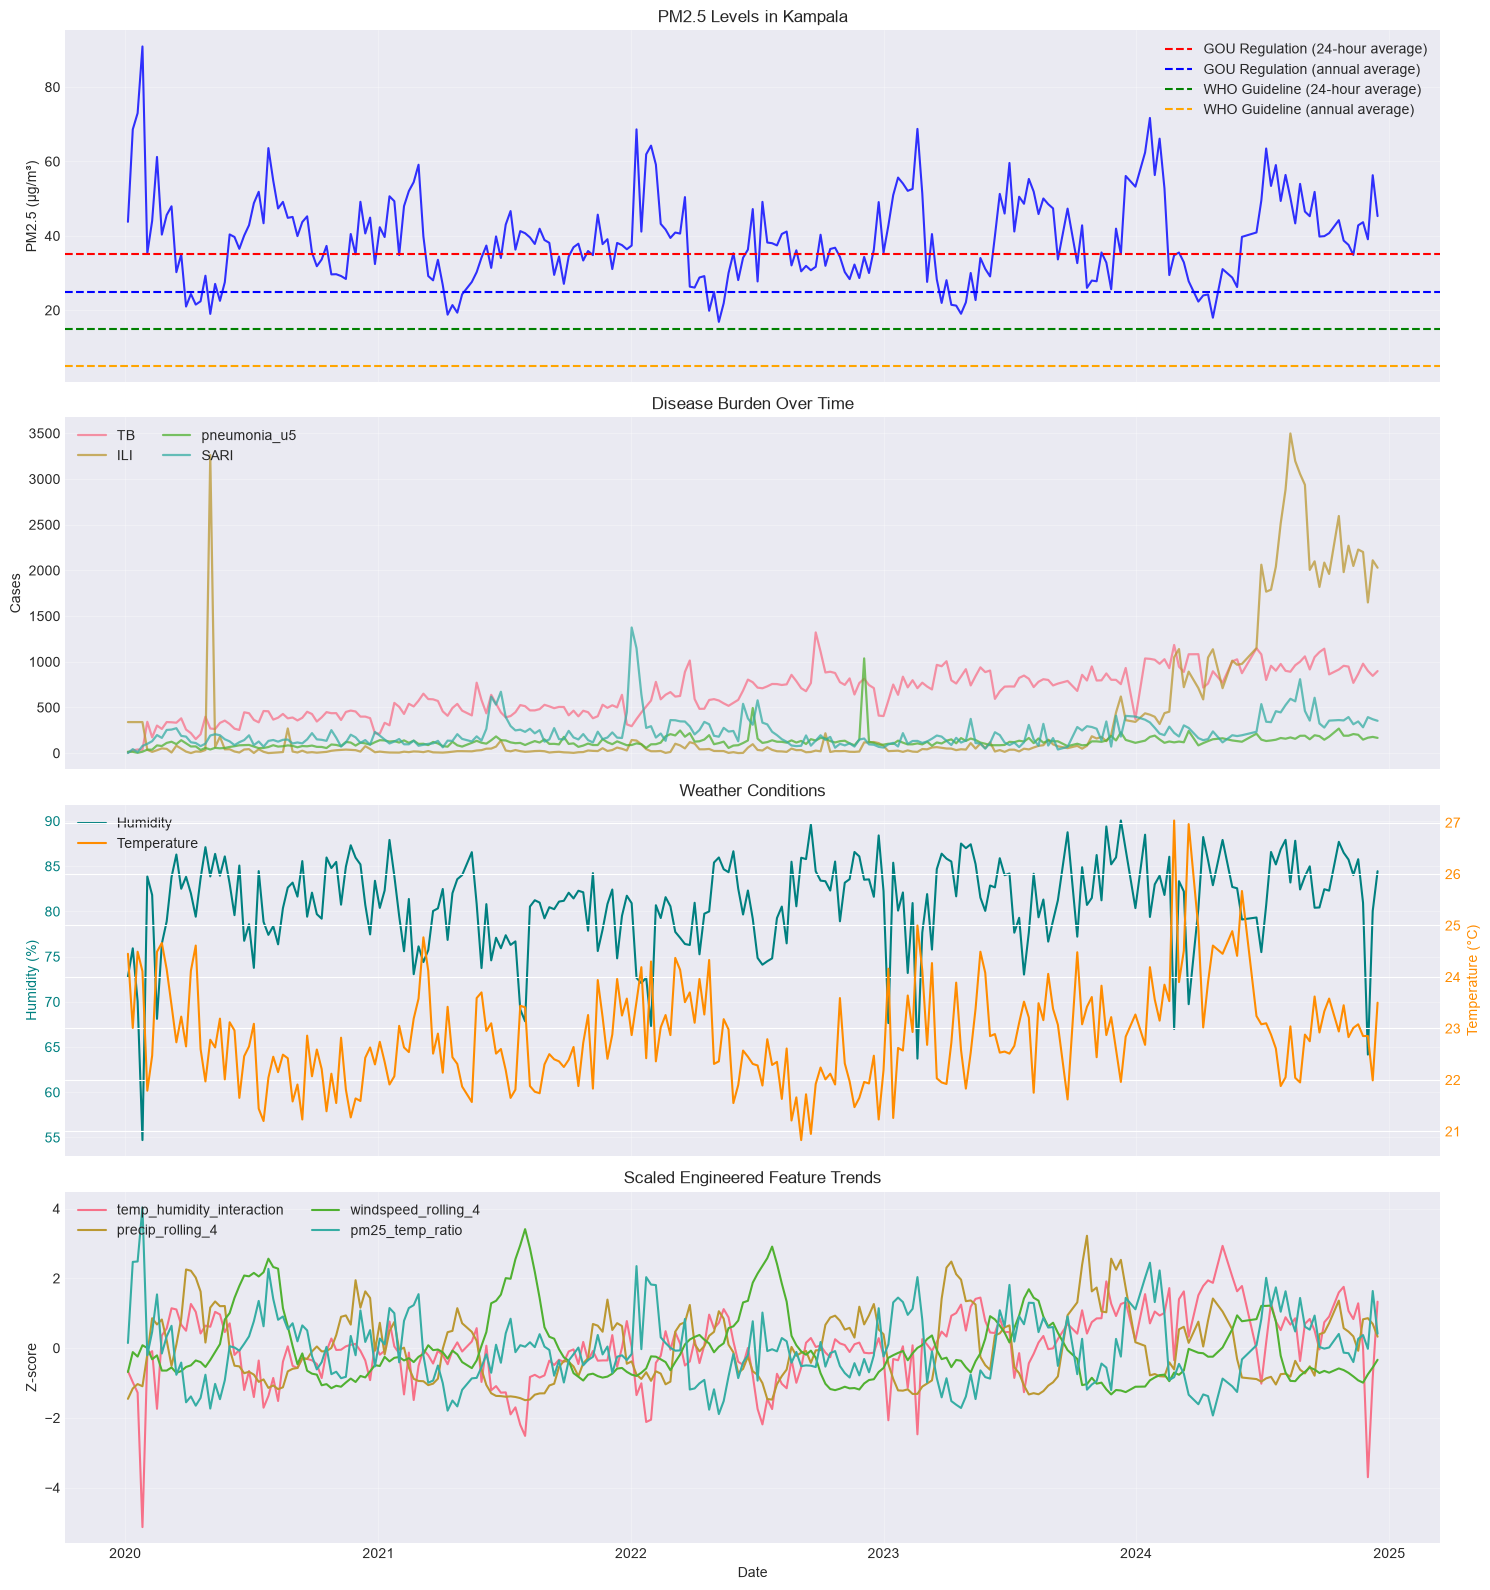

In [14]:
# Time series overview for air quality, diseases, and weather
disease_cols = [
    col for col in ['TB', 'ILI', 'pneumonia_u5', 'SARI']
    if col in processed_data.columns
]

fig, axes = plt.subplots(4, 1, figsize=(15, 16), sharex=True)

axes[0].plot(processed_data['date'], processed_data['pm2_5'], color='blue', alpha=0.8)
axes[0].axhline(y=35, color='red', linestyle='--', label='GOU Regulation (24-hour average)')
axes[0].axhline(y=25, color='blue', linestyle='--', label='GOU Regulation (annual average)')
axes[0].axhline(y=15, color='green', linestyle='--', label='WHO Guideline (24-hour average)')
axes[0].axhline(y=5, color='orange', linestyle='--', label='WHO Guideline (annual average)')
axes[0].set_title('PM2.5 Levels in Kampala')
axes[0].set_ylabel('PM2.5 (μg/m³)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for disease in disease_cols:
    axes[1].plot(processed_data['date'], processed_data[disease], alpha=0.75, linewidth=1.6, label=disease)
axes[1].set_title('Disease Burden Over Time')
axes[1].set_ylabel('Cases')
axes[1].legend(loc='upper left', ncol=2)
axes[1].grid(True, alpha=0.3)

weather_ax = axes[2]
temperature_ax = weather_ax.twinx()
weather_ax.plot(processed_data['date'], processed_data['avghumidity'], color='teal', label='Humidity')
temperature_ax.plot(processed_data['date'], processed_data['avgtemp'], color='darkorange', label='Temperature')
weather_ax.set_title('Weather Conditions')
weather_ax.set_ylabel('Humidity (%)', color='teal')
temperature_ax.set_ylabel('Temperature (°C)', color='darkorange')
weather_ax.tick_params(axis='y', labelcolor='teal')
temperature_ax.tick_params(axis='y', labelcolor='darkorange')
weather_ax.grid(True, alpha=0.3)
weather_handles, weather_labels = weather_ax.get_legend_handles_labels()
temp_handles, temp_labels = temperature_ax.get_legend_handles_labels()
weather_ax.legend(weather_handles + temp_handles, weather_labels + temp_labels, loc='upper left')

engineered_plot_cols = [
    col for col in ['temp_humidity_interaction', 'precip_rolling_4', 'windspeed_rolling_4', 'pm25_temp_ratio']
    if col in processed_data.columns
]
engineered_scaled = processed_data[engineered_plot_cols].copy()
for col in engineered_plot_cols:
    col_std = engineered_scaled[col].std()
    if pd.notna(col_std) and col_std != 0:
        engineered_scaled[col] = (engineered_scaled[col] - engineered_scaled[col].mean()) / col_std
    else:
        engineered_scaled[col] = 0
for col in engineered_plot_cols:
    axes[3].plot(processed_data['date'], engineered_scaled[col], linewidth=1.5, label=col)
axes[3].set_title('Scaled Engineered Feature Trends')
axes[3].set_ylabel('Z-score')
axes[3].set_xlabel('Date')
axes[3].legend(loc='upper left', ncol=2)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 2.2 Correlation Analysis


In [ ]:
# Correlation analysis across diseases and engineered features
disease_cols = [
    col for col in ['TB', 'ILI', 'pneumonia_u5', 'SARI']
    if col in processed_data.columns
]
feature_analysis_cols = [
    col for col in [
        'pm2_5', 'avgtemp', 'avghumidity', 'avgtemp_sat', 'humidity_sat',
        'windspeed', 'precip', 'pm25_lag_1', 'pm25_lag_2',
        'pm25_ma_7', 'pm25_ma_14',
        'pm25_ma_30', 'pm25_trailing_ma_7',
        'pm25_trailing_ma_14', 'pm25_trailing_ma_30',
        'pm25_temp_ratio', 'pm25_humidity_ratio',
        'time_since_intervention'
    ]
    if col in processed_data.columns
]

feature_corr_matrix = processed_data[feature_analysis_cols].corr()
plt.figure(figsize=(16, 12))
sns.heatmap(feature_corr_matrix, cmap='coolwarm', center=0)
plt.title('Correlation Matrix for Environmental and Engineered Features')
plt.tight_layout()
plt.show()

disease_feature_corr = processed_data[disease_cols + feature_analysis_cols].corr().loc[disease_cols, feature_analysis_cols]
plt.figure(figsize=(18, max(4, len(disease_cols) * 1.2)))
sns.heatmap(disease_feature_corr, annot=True, cmap='vlag', center=0, fmt='.2f')
plt.title('Disease-to-Feature Correlation Matrix')
plt.tight_layout()
plt.show()


### 2.3 Disease-Level Feature Ranking


In [ ]:
# Disease-level feature ranking and pairwise relationships
disease_cols = [
    col for col in ['TB', 'ILI', 'pneumonia_u5', 'SARI']
    if col in processed_data.columns
]
feature_analysis_cols = [
    col for col in [
        'pm2_5', 'avgtemp', 'avghumidity', 'avgtemp_sat', 'humidity_sat',
        'windspeed', 'precip', 'pm25_lag_1', 'pm25_lag_2',
        'pm25_ma_7', 'pm25_ma_14',
        'pm25_ma_30', 'pm25_trailing_ma_7',
        'pm25_trailing_ma_14', 'pm25_trailing_ma_30',
        'pm25_temp_ratio', 'pm25_humidity_ratio',
        'time_since_intervention'
    ]
    if col in processed_data.columns
]

disease_feature_corr = processed_data[disease_cols + feature_analysis_cols].corr().loc[disease_cols, feature_analysis_cols]
strongest_links = (
    disease_feature_corr.abs()
    .stack()
    .reset_index(name='abs_correlation')
    .rename(columns={'level_0': 'disease', 'level_1': 'feature'})
    .sort_values(['disease', 'abs_correlation'], ascending=[True, False])
    .groupby('disease')
    .head(5)
)
strongest_links['correlation'] = strongest_links.apply(
    lambda row: disease_feature_corr.loc[row['disease'], row['feature']],
    axis=1
)
print('Top 5 absolute correlations per disease')
print(strongest_links[['disease', 'feature', 'correlation', 'abs_correlation']].to_string(index=False))

summary_stats = processed_data[disease_cols + feature_analysis_cols].describe().T[['mean', 'std', 'min', 'max']].round(2)
summary_stats.head(20)


### 2.4 PM2.5 vs Disease Scatter Plots


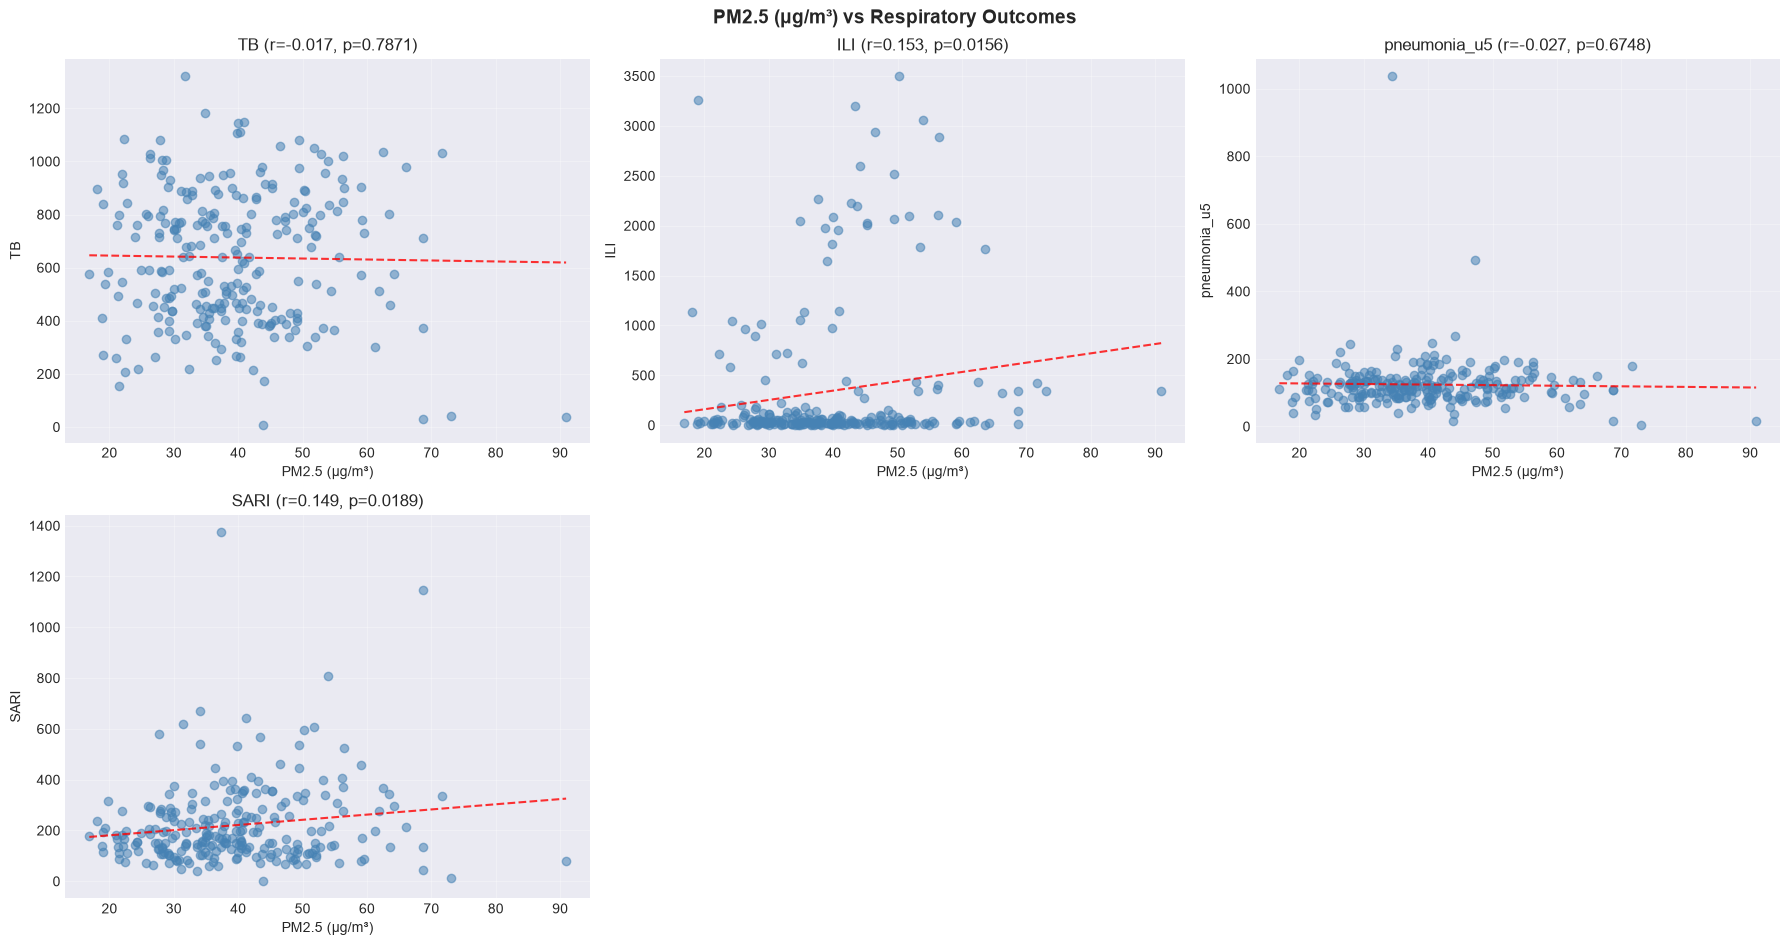

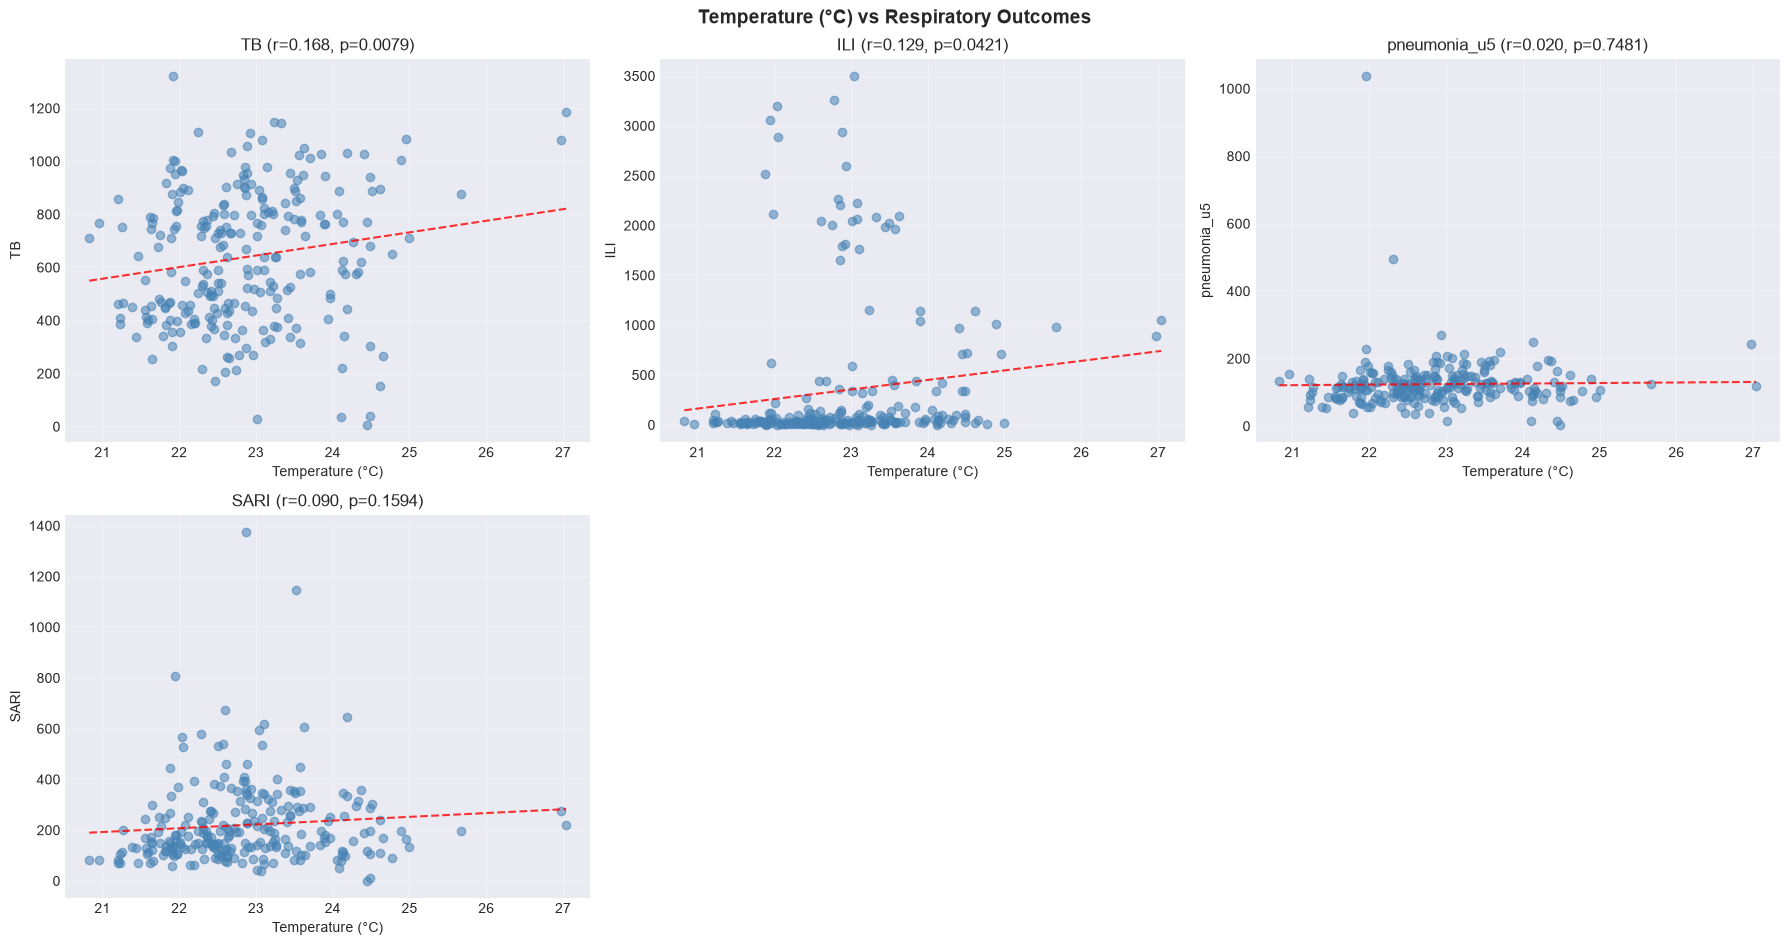

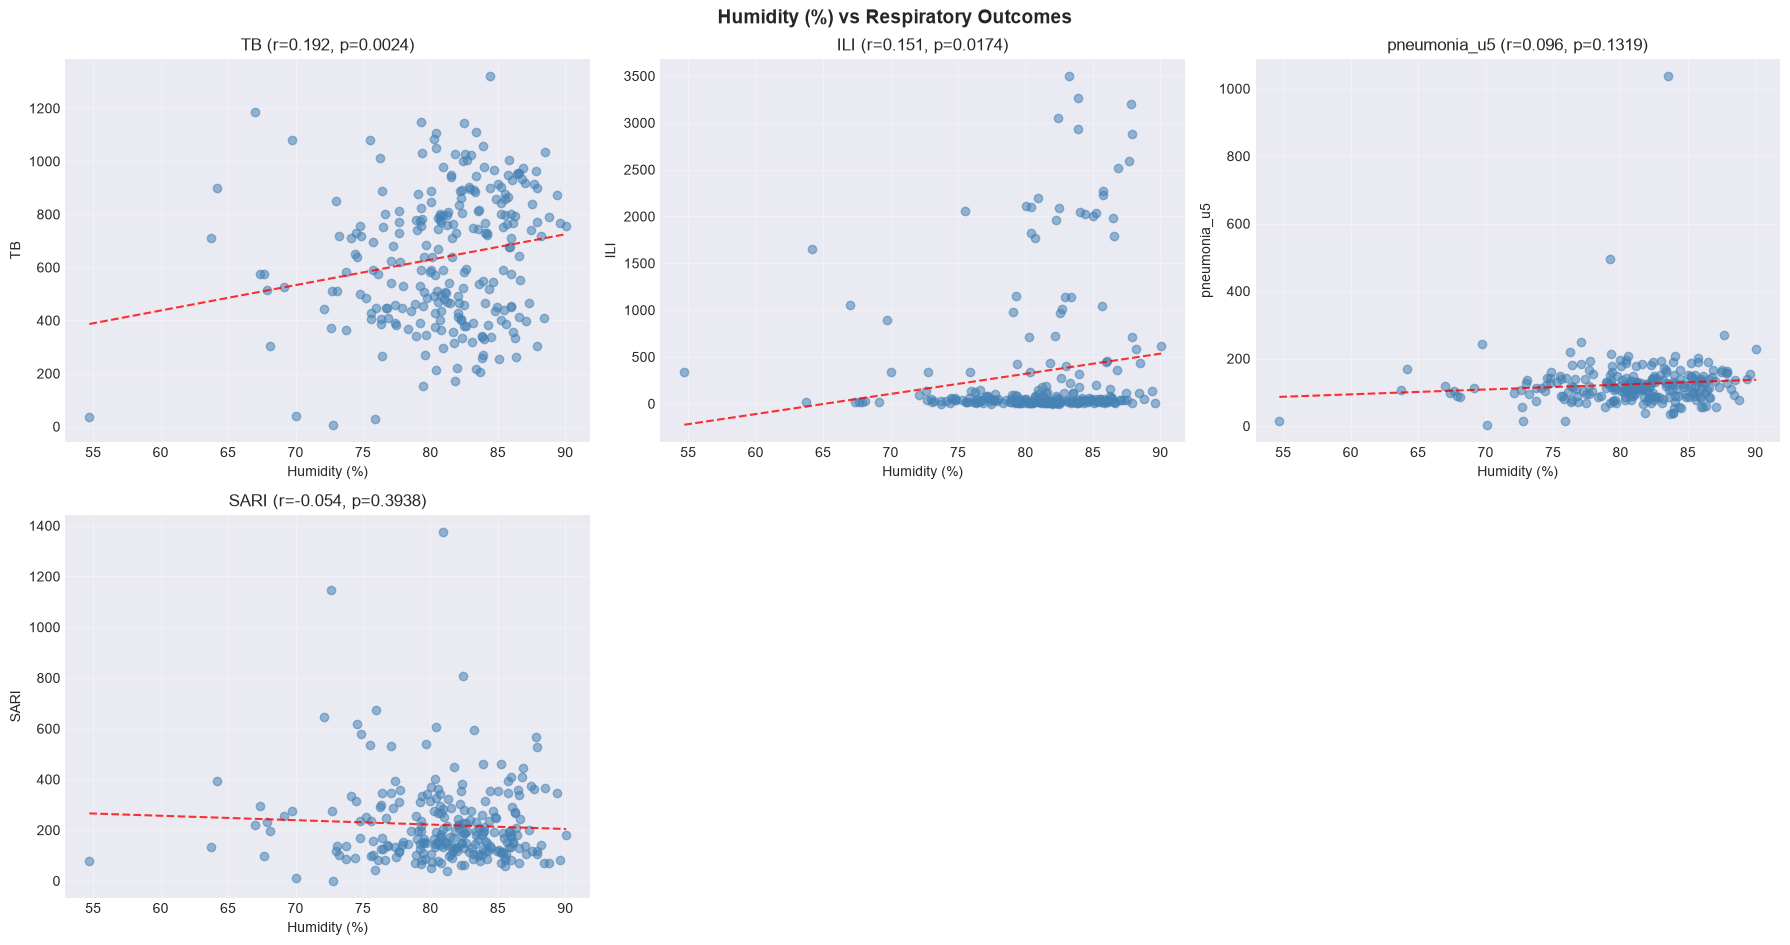

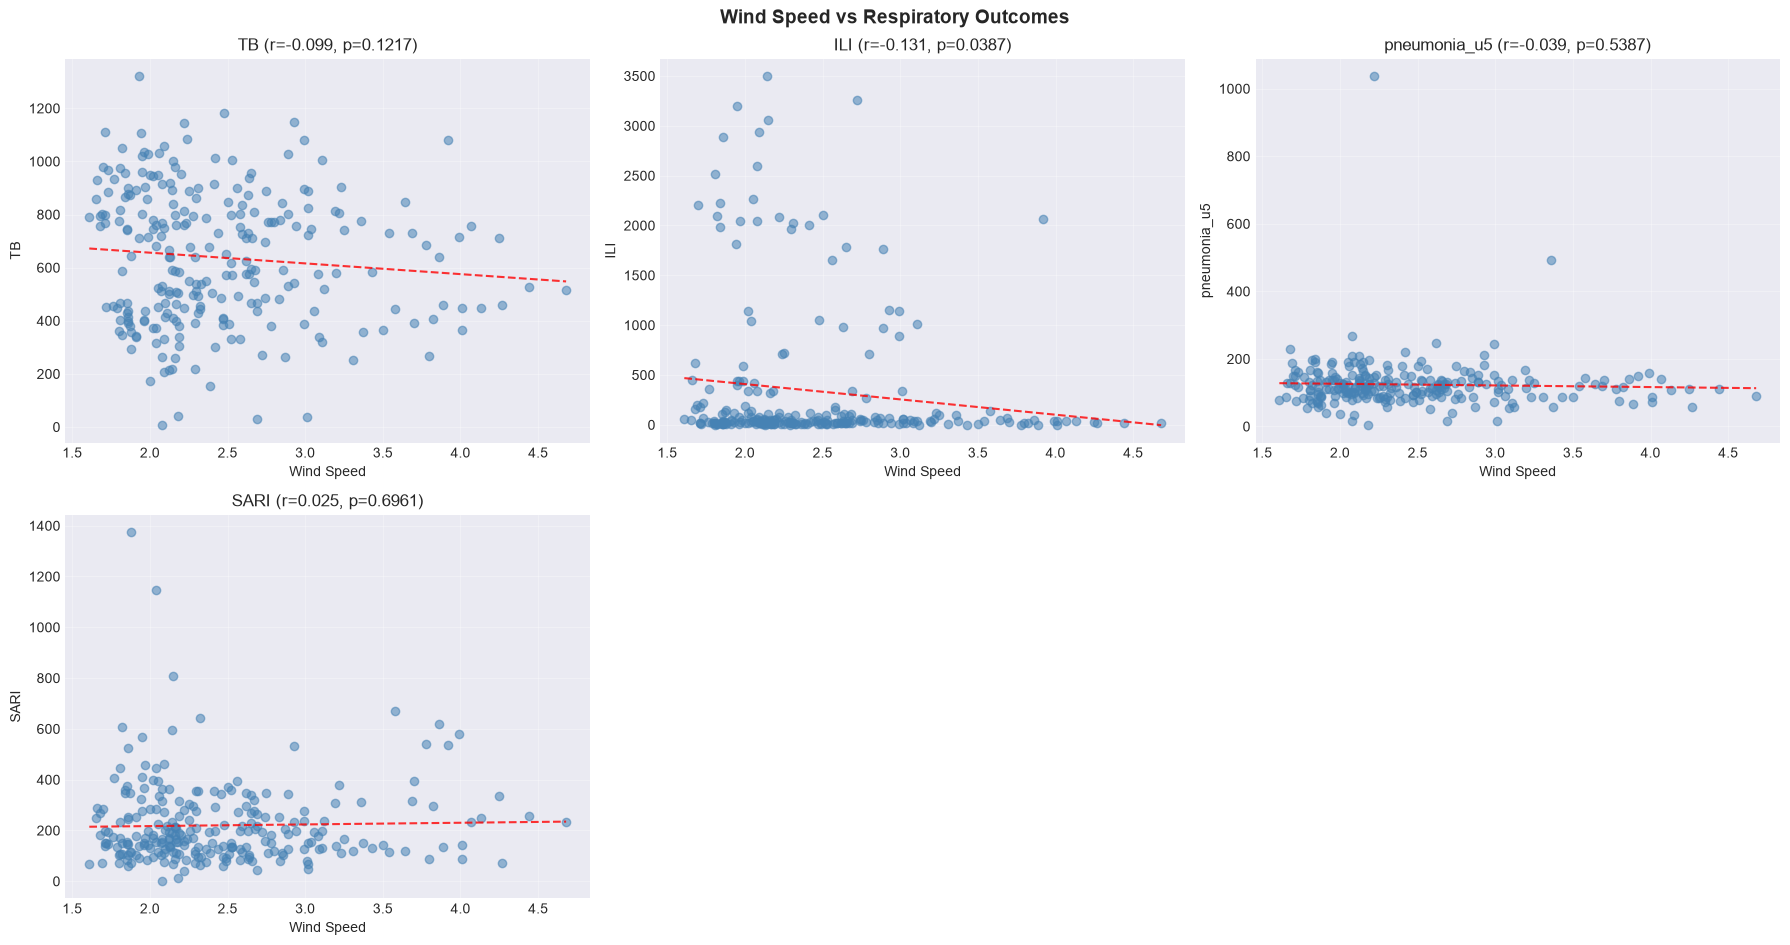

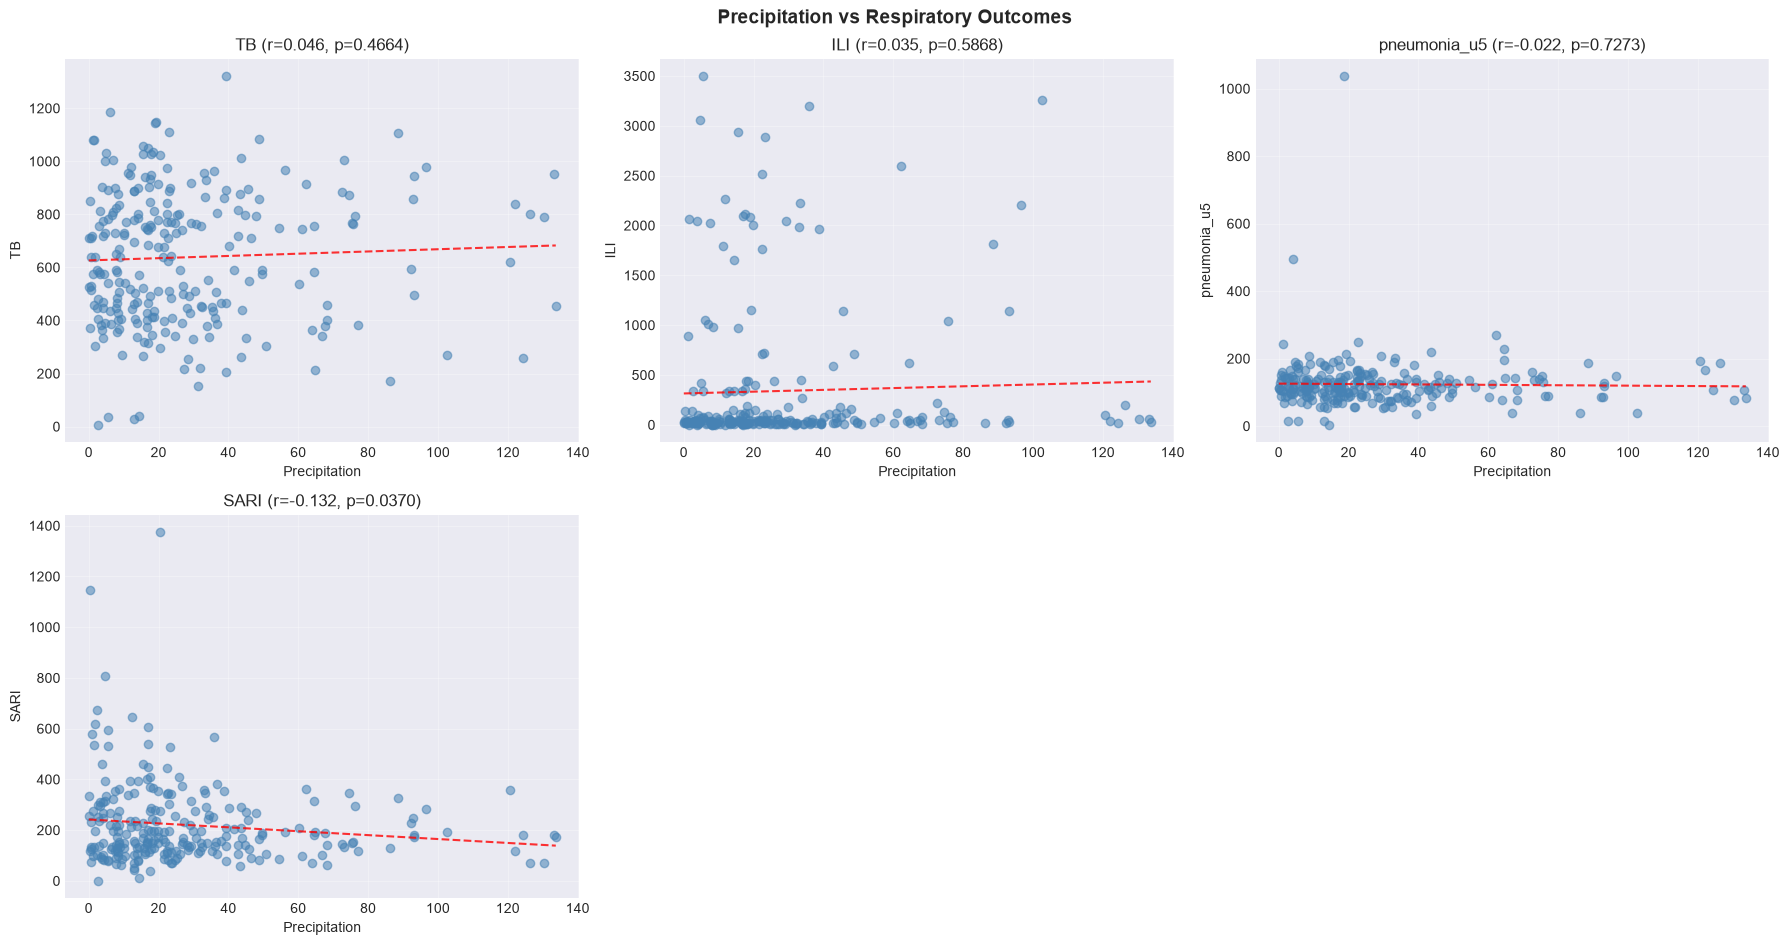

In [17]:
# Core air-quality and climate variables vs disease scatter plots with regression lines
import math
import scipy.stats as stats

disease_cols = [
    col for col in ['TB', 'ILI', 'pneumonia_u5', 'SARI']
    if col in processed_data.columns
]
core_feature_labels = {
    'pm2_5': 'PM2.5 (μg/m³)',
    'avgtemp': 'Temperature (°C)',
    'avghumidity': 'Humidity (%)',
    'windspeed': 'Wind Speed',
    'precip': 'Precipitation'
}
core_feature_cols = [col for col in core_feature_labels if col in processed_data.columns]

for feature in core_feature_cols:
    ncols = 3
    nrows = math.ceil(len(disease_cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.8 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, disease in zip(axes, disease_cols):
        plot_data = processed_data[[feature, disease]].dropna()
        if len(plot_data) < 2:
            ax.text(0.5, 0.5, f'Not enough data for {disease}', ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
            continue

        ax.scatter(plot_data[feature], plot_data[disease], alpha=0.55, color='steelblue')
        slope, intercept = np.polyfit(plot_data[feature], plot_data[disease], 1)
        regression = np.poly1d((slope, intercept))
        x_sorted = np.sort(plot_data[feature].to_numpy())
        ax.plot(x_sorted, regression(x_sorted), 'r--', alpha=0.8)

        corr, p_value = stats.pearsonr(plot_data[feature], plot_data[disease])
        ax.set_title(f'{disease} (r={corr:.3f}, p={p_value:.4f})')
        ax.set_xlabel(core_feature_labels[feature])
        ax.set_ylabel(disease)
        ax.grid(True, alpha=0.3)

    for ax in axes[len(disease_cols):]:
        ax.set_axis_off()

    plt.suptitle(f'{core_feature_labels[feature]} vs Respiratory Outcomes', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


### 2.5 Seasonal Analysis


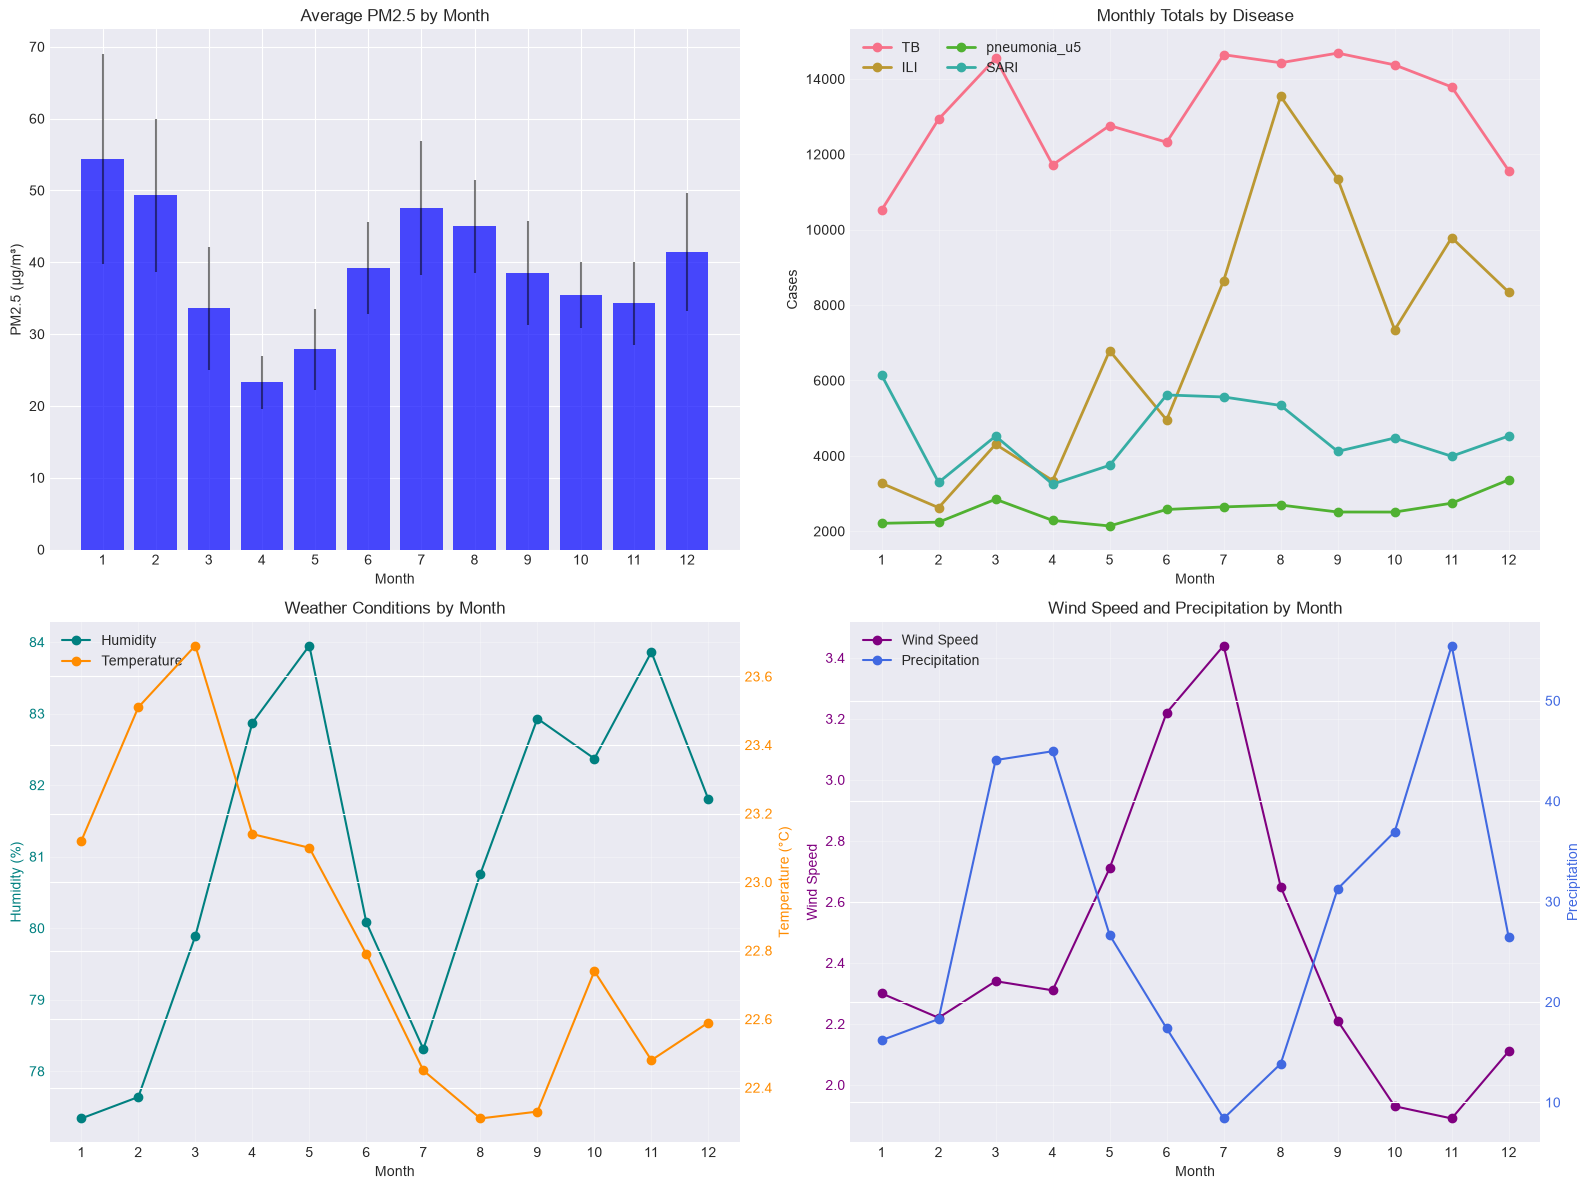

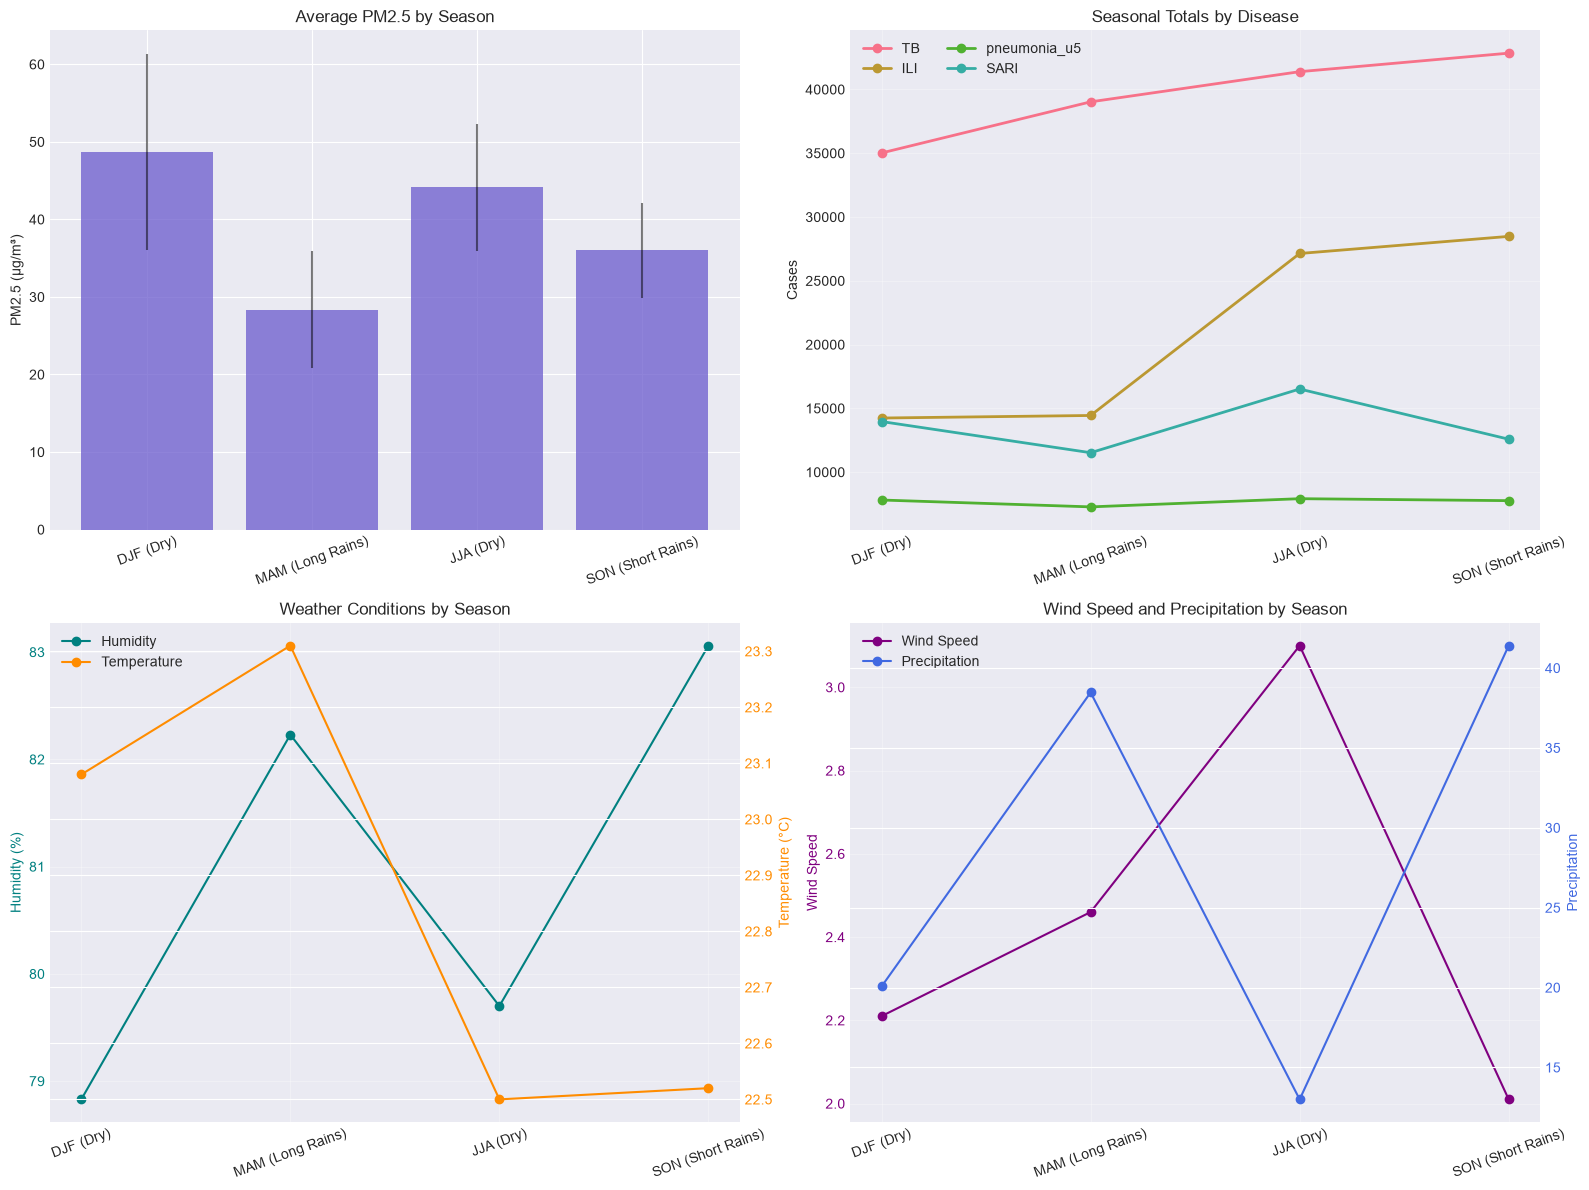

(             TB      ILI  pneumonia_u5    SARI
 month                                         
 1      10520.26   3273.8        2211.0  6143.0
 2      12933.00   2626.0        2241.0  3297.0
 3      14544.00   4307.0        2849.0  4524.0
 4      11721.00   3346.0        2288.0  3250.0
 5      12763.00   6790.0        2141.0  3750.0
 6      12321.26   4954.0        2578.0  5616.0
 7      14643.00   8647.0        2646.0  5563.0
 8      14429.00  13540.0        2696.0  5338.0
 9      14685.00  11349.0        2511.0  4119.0
 10     14372.00   7344.0        2510.0  4474.0
 11     13788.00   9788.0        2745.0  3990.0
 12     11568.26   8343.0        3364.0  4527.0,
                          TB      ILI  pneumonia_u5     SARI
 season                                                     
 DJF (Dry)          35021.51  14242.8        7816.0  13967.0
 MAM (Long Rains)   39028.00  14443.0        7278.0  11524.0
 JJA (Dry)          41393.26  27141.0        7920.0  16517.0
 SON (Short Rains)  42

In [18]:
# Monthly and seasonal patterns across all diseases and key features
processed_data['month'] = processed_data['date'].dt.month
processed_data['season'] = processed_data['month'].map({
    12: 'DJF (Dry)', 1: 'DJF (Dry)', 2: 'DJF (Dry)',
    3: 'MAM (Long Rains)', 4: 'MAM (Long Rains)', 5: 'MAM (Long Rains)',
    6: 'JJA (Dry)', 7: 'JJA (Dry)', 8: 'JJA (Dry)',
    9: 'SON (Short Rains)', 10: 'SON (Short Rains)', 11: 'SON (Short Rains)'
})

disease_cols = [
    col for col in ['TB', 'ILI', 'pneumonia_u5', 'SARI']
    if col in processed_data.columns
]
monthly_feature_cols = [
    col for col in ['pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip']
    if col in processed_data.columns
]
monthly_agg = {col: ['mean', 'std'] for col in monthly_feature_cols}
monthly_agg.update({col: ['mean', 'sum'] for col in disease_cols})
monthly_stats = processed_data.groupby('month').agg(monthly_agg).reindex(range(1, 13)).round(2)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].bar(range(1, 13), monthly_stats['pm2_5']['mean'].values, color='blue', alpha=0.7)
axes[0, 0].errorbar(
    range(1, 13),
    monthly_stats['pm2_5']['mean'].values,
    yerr=monthly_stats['pm2_5']['std'].fillna(0).values,
    fmt='none',
    color='black',
    alpha=0.5
)
axes[0, 0].set_title('Average PM2.5 by Month')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('PM2.5 (μg/m³)')
axes[0, 0].set_xticks(range(1, 13))

for disease in disease_cols:
    axes[0, 1].plot(range(1, 13), monthly_stats[disease]['sum'].values, marker='o', linewidth=2, label=disease)
axes[0, 1].set_title('Monthly Totals by Disease')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Cases')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].legend(loc='upper left', ncol=2)
axes[0, 1].grid(True, alpha=0.3)

monthly_weather_ax = axes[1, 0]
monthly_temperature_ax = monthly_weather_ax.twinx()
monthly_weather_ax.plot(range(1, 13), monthly_stats['avghumidity']['mean'].values, 'o-', color='teal', label='Humidity')
monthly_temperature_ax.plot(range(1, 13), monthly_stats['avgtemp']['mean'].values, 'o-', color='darkorange', label='Temperature')
monthly_weather_ax.set_title('Weather Conditions by Month')
monthly_weather_ax.set_xlabel('Month')
monthly_weather_ax.set_ylabel('Humidity (%)', color='teal')
monthly_temperature_ax.set_ylabel('Temperature (°C)', color='darkorange')
monthly_weather_ax.tick_params(axis='y', labelcolor='teal')
monthly_temperature_ax.tick_params(axis='y', labelcolor='darkorange')
monthly_weather_ax.set_xticks(range(1, 13))
monthly_weather_ax.grid(True, alpha=0.3)
monthly_handles, monthly_labels = monthly_weather_ax.get_legend_handles_labels()
monthly_temp_handles, monthly_temp_labels = monthly_temperature_ax.get_legend_handles_labels()
monthly_weather_ax.legend(monthly_handles + monthly_temp_handles, monthly_labels + monthly_temp_labels, loc='upper left')

monthly_wind_ax = axes[1, 1]
monthly_precip_ax = monthly_wind_ax.twinx()
if 'windspeed' in monthly_feature_cols:
    monthly_wind_ax.plot(range(1, 13), monthly_stats['windspeed']['mean'].values, 'o-', color='purple', label='Wind Speed')
if 'precip' in monthly_feature_cols:
    monthly_precip_ax.plot(range(1, 13), monthly_stats['precip']['mean'].values, 'o-', color='royalblue', label='Precipitation')
monthly_wind_ax.set_title('Wind Speed and Precipitation by Month')
monthly_wind_ax.set_xlabel('Month')
monthly_wind_ax.set_ylabel('Wind Speed', color='purple')
monthly_precip_ax.set_ylabel('Precipitation', color='royalblue')
monthly_wind_ax.tick_params(axis='y', labelcolor='purple')
monthly_precip_ax.tick_params(axis='y', labelcolor='royalblue')
monthly_wind_ax.set_xticks(range(1, 13))
monthly_wind_ax.grid(True, alpha=0.3)
monthly_wind_handles, monthly_wind_labels = monthly_wind_ax.get_legend_handles_labels()
monthly_precip_handles, monthly_precip_labels = monthly_precip_ax.get_legend_handles_labels()
monthly_wind_ax.legend(monthly_wind_handles + monthly_precip_handles, monthly_wind_labels + monthly_precip_labels, loc='upper left')

plt.tight_layout()
plt.show()

season_order = ['DJF (Dry)', 'MAM (Long Rains)', 'JJA (Dry)', 'SON (Short Rains)']
seasonal_stats = processed_data.groupby('season').agg(monthly_agg).reindex(season_order).round(2)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].bar(season_order, seasonal_stats['pm2_5']['mean'].values, color='slateblue', alpha=0.75)
axes[0, 0].errorbar(
    season_order,
    seasonal_stats['pm2_5']['mean'].values,
    yerr=seasonal_stats['pm2_5']['std'].fillna(0).values,
    fmt='none',
    color='black',
    alpha=0.5
)
axes[0, 0].set_title('Average PM2.5 by Season')
axes[0, 0].set_ylabel('PM2.5 (μg/m³)')
axes[0, 0].tick_params(axis='x', rotation=20)

for disease in disease_cols:
    axes[0, 1].plot(season_order, seasonal_stats[disease]['sum'].values, marker='o', linewidth=2, label=disease)
axes[0, 1].set_title('Seasonal Totals by Disease')
axes[0, 1].set_ylabel('Cases')
axes[0, 1].tick_params(axis='x', rotation=20)
axes[0, 1].legend(loc='upper left', ncol=2)
axes[0, 1].grid(True, alpha=0.3)

seasonal_weather_ax = axes[1, 0]
seasonal_temperature_ax = seasonal_weather_ax.twinx()
seasonal_weather_ax.plot(season_order, seasonal_stats['avghumidity']['mean'].values, 'o-', color='teal', label='Humidity')
seasonal_temperature_ax.plot(season_order, seasonal_stats['avgtemp']['mean'].values, 'o-', color='darkorange', label='Temperature')
seasonal_weather_ax.set_title('Weather Conditions by Season')
seasonal_weather_ax.set_ylabel('Humidity (%)', color='teal')
seasonal_temperature_ax.set_ylabel('Temperature (°C)', color='darkorange')
seasonal_weather_ax.tick_params(axis='y', labelcolor='teal')
seasonal_temperature_ax.tick_params(axis='y', labelcolor='darkorange')
seasonal_weather_ax.tick_params(axis='x', rotation=20)
seasonal_weather_ax.grid(True, alpha=0.3)
seasonal_handles, seasonal_labels = seasonal_weather_ax.get_legend_handles_labels()
seasonal_temp_handles, seasonal_temp_labels = seasonal_temperature_ax.get_legend_handles_labels()
seasonal_weather_ax.legend(seasonal_handles + seasonal_temp_handles, seasonal_labels + seasonal_temp_labels, loc='upper left')

seasonal_wind_ax = axes[1, 1]
seasonal_precip_ax = seasonal_wind_ax.twinx()
if 'windspeed' in monthly_feature_cols:
    seasonal_wind_ax.plot(season_order, seasonal_stats['windspeed']['mean'].values, 'o-', color='purple', label='Wind Speed')
if 'precip' in monthly_feature_cols:
    seasonal_precip_ax.plot(season_order, seasonal_stats['precip']['mean'].values, 'o-', color='royalblue', label='Precipitation')
seasonal_wind_ax.set_title('Wind Speed and Precipitation by Season')
seasonal_wind_ax.set_ylabel('Wind Speed', color='purple')
seasonal_precip_ax.set_ylabel('Precipitation', color='royalblue')
seasonal_wind_ax.tick_params(axis='y', labelcolor='purple')
seasonal_precip_ax.tick_params(axis='y', labelcolor='royalblue')
seasonal_wind_ax.tick_params(axis='x', rotation=20)
seasonal_wind_ax.grid(True, alpha=0.3)
seasonal_wind_handles, seasonal_wind_labels = seasonal_wind_ax.get_legend_handles_labels()
seasonal_precip_handles, seasonal_precip_labels = seasonal_precip_ax.get_legend_handles_labels()
seasonal_wind_ax.legend(seasonal_wind_handles + seasonal_precip_handles, seasonal_wind_labels + seasonal_precip_labels, loc='upper left')

plt.tight_layout()
plt.show()

monthly_disease_totals = monthly_stats.loc[:, pd.IndexSlice[disease_cols, 'sum']]
monthly_disease_totals.columns = [col for col, _ in monthly_disease_totals.columns]
seasonal_disease_totals = seasonal_stats.loc[:, pd.IndexSlice[disease_cols, 'sum']]
seasonal_disease_totals.columns = [col for col, _ in seasonal_disease_totals.columns]

monthly_disease_totals, seasonal_disease_totals


## 6. Spatial and facility heterogeneity

Division-level maps and facility records are presented here to assess geographic heterogeneity. They are descriptive unless the data support an explicitly adjusted multilevel model.


,division,parishes,population_male,population_female,population_total,population_age_0_4,population_age_6_12,population_age_13_18,population_age_14_64,population_age_65_plus
0,Kampala Central,20,48204,33454,81658,7058,9154,9248,60890,1736
1,Kawempe,22,230649,159521,390170,45935,54658,48063,264863,8269
2,Makindye,23,264968,221794,486762,54755,65989,61320,336522,9349
3,Nakawa,23,227129,201603,428732,49999,57247,51556,296433,7358
4,Rubaga,13,233934,176466,410400,49718,58204,51751,276554,8580


Interpret rates and model estimates as associations with recorded facility cases, not population incidence.
Parish results remain descriptive unless the crosswalk and boundary checks are approved.


,metric,value
0,medical_records_linked_window,5006
1,parish_exact_or_reviewed_match,2425
2,records_with_same_day_division_pm25,3632
3,monitor_days,1596
4,monitor_sites,9


,division,mean_pm25,recorded_cases,mean_rate_per_100k,monitor_sites,records,parish_matched,pm25_matched
0,Kampala Central,42.299678,105,15.229409,1.000000,321,28,105
1,Kawempe,41.076424,276,2.379981,2.456271,350,51,278
2,Makindye,43.633337,953,2.755553,1.625127,1103,485,961
3,Nakawa,32.259657,1077,5.046323,1.733381,1333,649,1099
4,Rubaga,58.964294,1175,4.860470,1.000000,1899,1212,1189


,division,sex,age_band,diagnosis,recorded_cases,mean_pm25,mean_rate_per_100k,periods
0,Kampala Central,Female,0-4,Tuberculosis,1,40.994150,34.583507,1
1,Kampala Central,Female,13-18,Tuberculosis,1,16.611675,26.393857,1
2,Kampala Central,Female,19-64,Pneumonia,2,47.043354,4.008711,2
3,Kampala Central,Female,19-64,Severe Acute Respiratory Infections,5,31.285608,6.681184,3
4,Kampala Central,Female,19-64,Tuberculosis,16,49.006882,5.830852,11
5,Kampala Central,Female,6-12,Tuberculosis,2,51.802729,26.664889,2
6,Kampala Central,Female,65+,Severe Acute Respiratory Infections,1,44.441475,140.605065,1
7,Kampala Central,Female,65+,Severe Pneumonia,1,57.265304,140.605065,1
8,Kampala Central,Male,0-4,Tuberculosis,2,38.242144,24.001258,2
9,Kampala Central,Male,13-18,Tuberculosis,4,25.127146,24.423426,3


,division,parish_raw,parish_key,parish_matched,records,first_visit,last_visit
388,Nakawa,Mbuya,mbuya,False,148,2020-01-07,2024-10-18
402,Nakawa,Naguru,naguru,False,132,2020-01-03,2024-08-08
240,Makindye,Makindye,makindye,False,107,2020-01-14,2024-11-19
287,Makindye,Nsambya,nsambya,False,85,2020-02-06,2024-12-05
462,Rubaga,Kawaala,kawaala,False,85,2020-01-28,2024-12-02
494,Rubaga,Kitebi,kitebi,False,77,2020-05-11,2024-12-09
30,Kampala Central,Kisenyi,kisenyi,False,75,2020-04-15,2024-08-05
588,Rubaga,Wankulukuku,wankulukuku,False,55,2020-05-27,2024-12-07
93,Kawempe,Kawempe,kawempe,False,52,2020-01-06,2024-08-07
17,Kampala Central,Kamwokya,kamwokya,False,50,2020-02-18,2024-03-11


,diagnosis,status,n,within_division_irr_per_10ug_m3,ci_low,ci_high,pearson_overdispersion
0,Influenza Like Illness,ok,85,1.090111,0.965858,1.230347,0.226160
1,Pneumonia,ok,173,1.059566,0.995493,1.127762,0.240398
2,Severe Acute Respiratory Infections,ok,78,0.957739,0.863547,1.062205,0.329529
3,Severe Pneumonia,insufficient data,14,NaN,NaN,NaN,NaN
4,Tuberculosis,ok,1332,1.001083,0.978204,1.024498,0.369629


,diagnosis,odds_ratio_per_10ug_m3,ci_low,ci_high,n,status
0,Influenza Like Illness,1.748975,1.489936,2.053051,3586,ok
1,Pneumonia,0.902058,0.806352,1.009125,3586,ok
2,Severe Acute Respiratory Infections,0.883850,0.778026,1.004068,3586,ok
3,Severe Pneumonia,NaN,NaN,NaN,3586,insufficient cases
4,Tuberculosis,0.847829,0.778940,0.922811,3586,ok


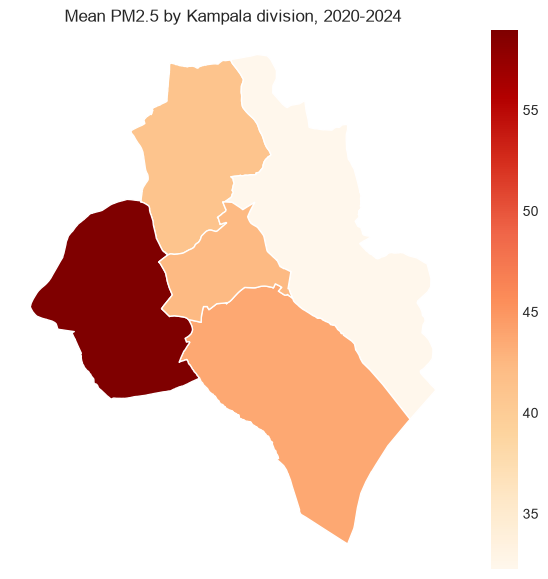

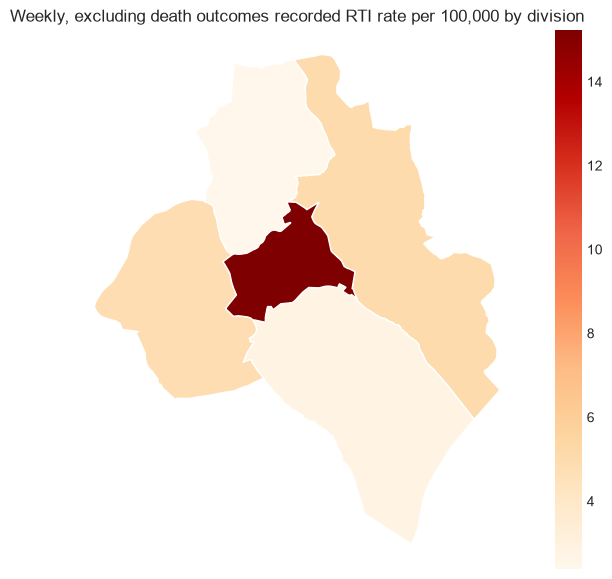

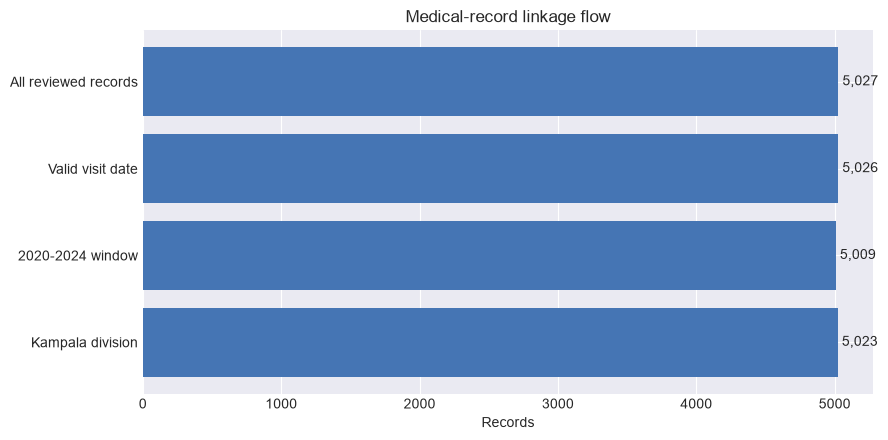

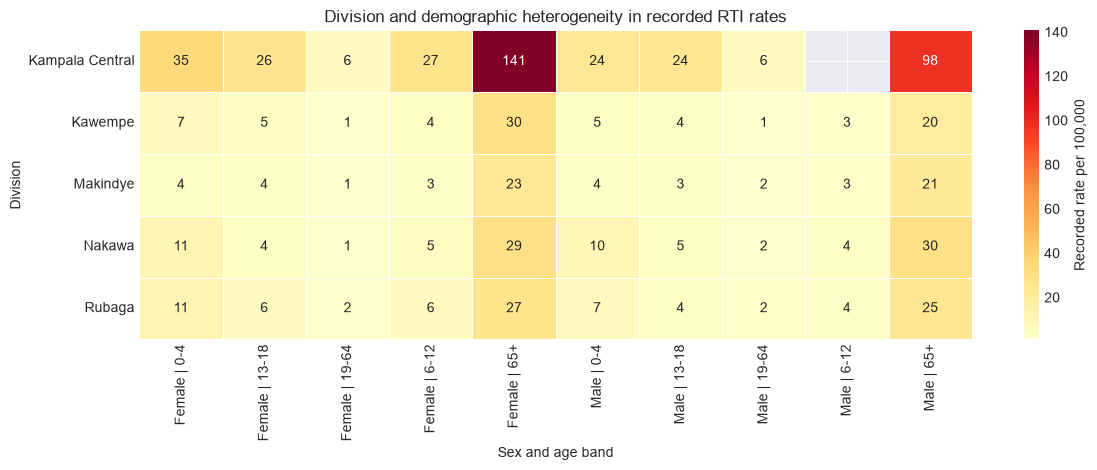

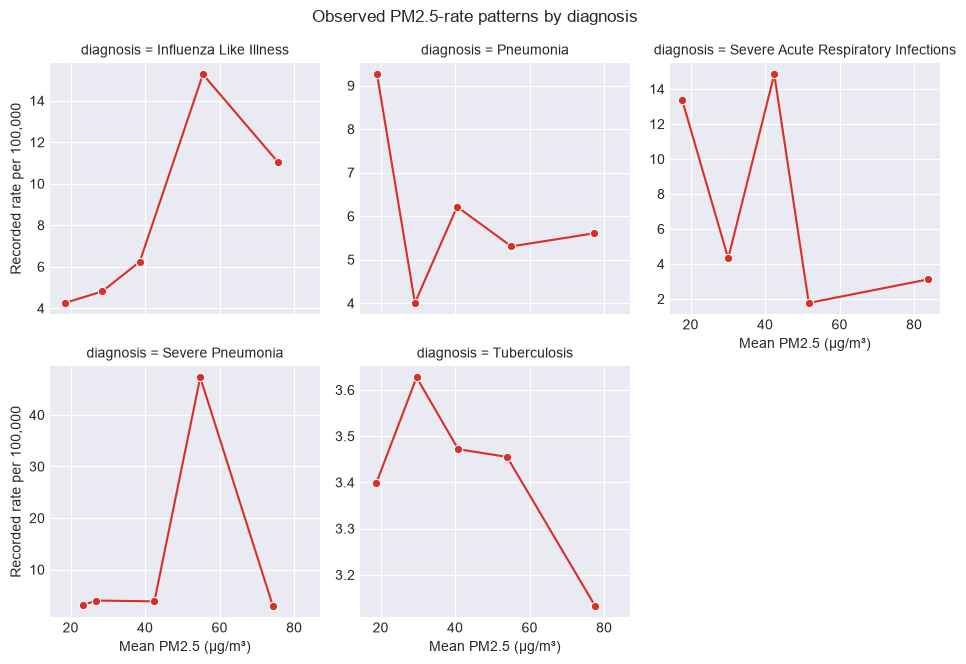

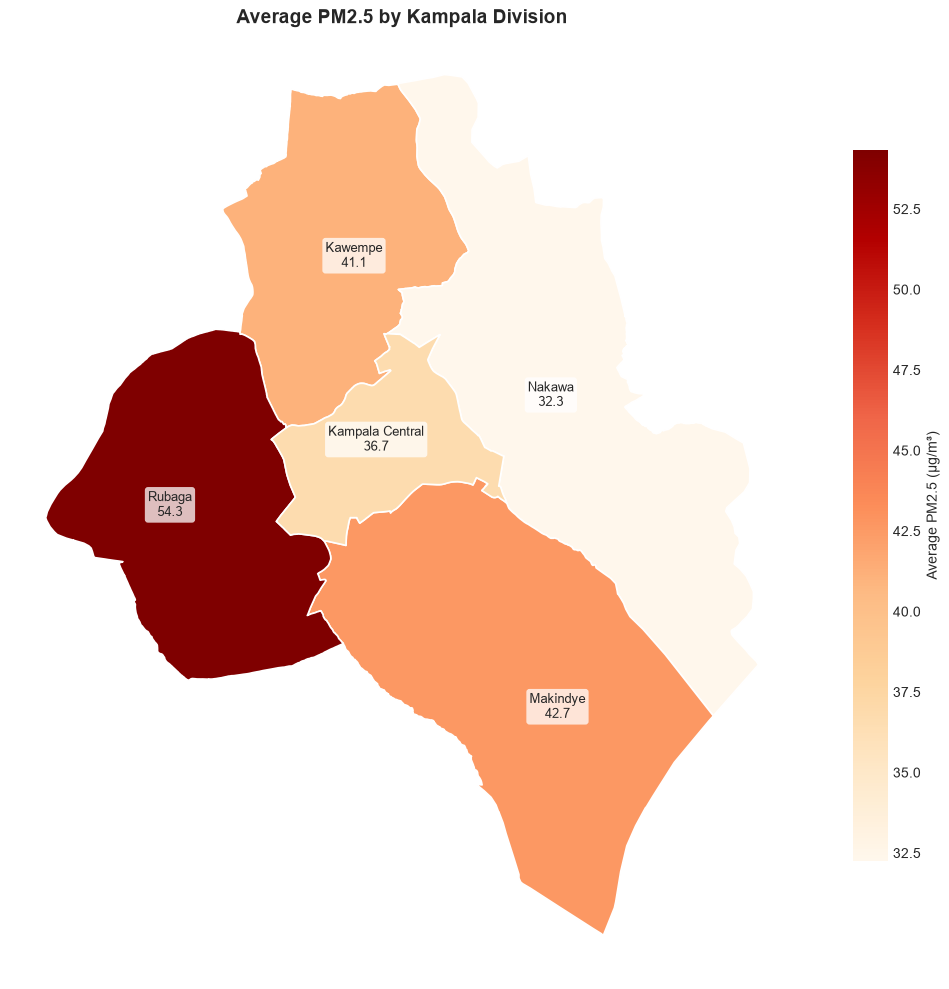

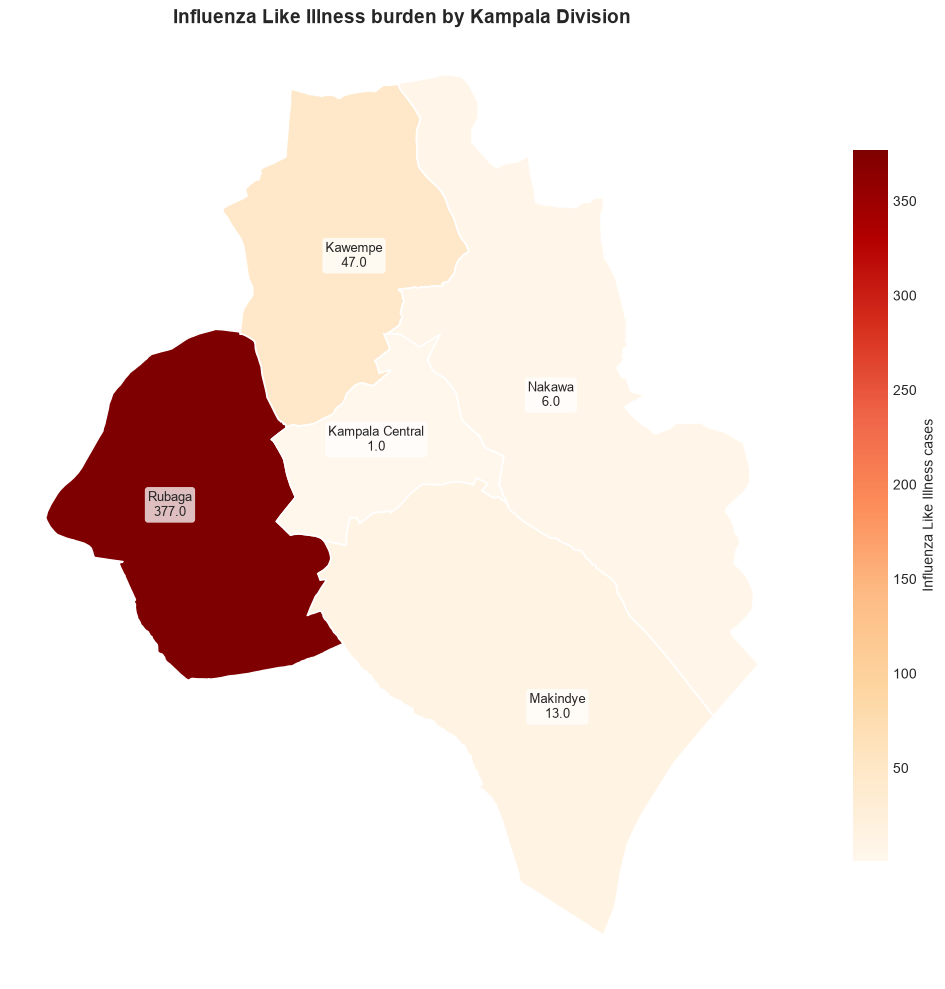

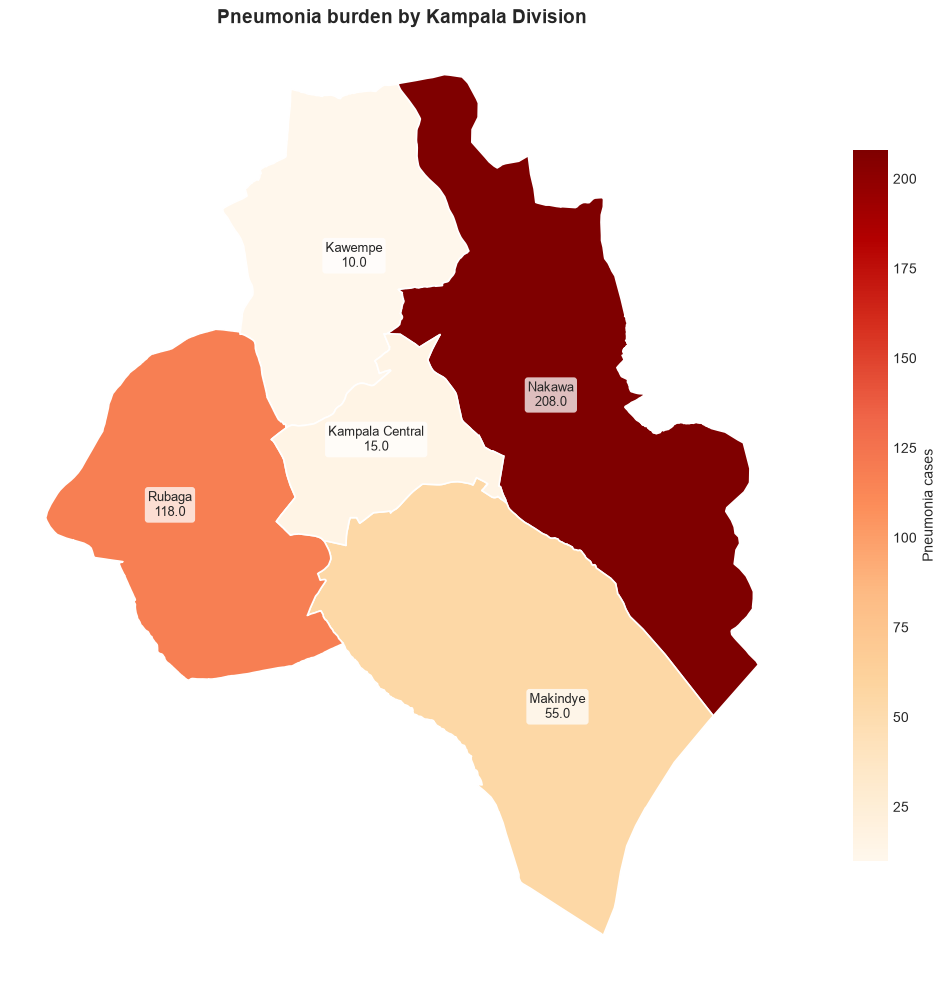

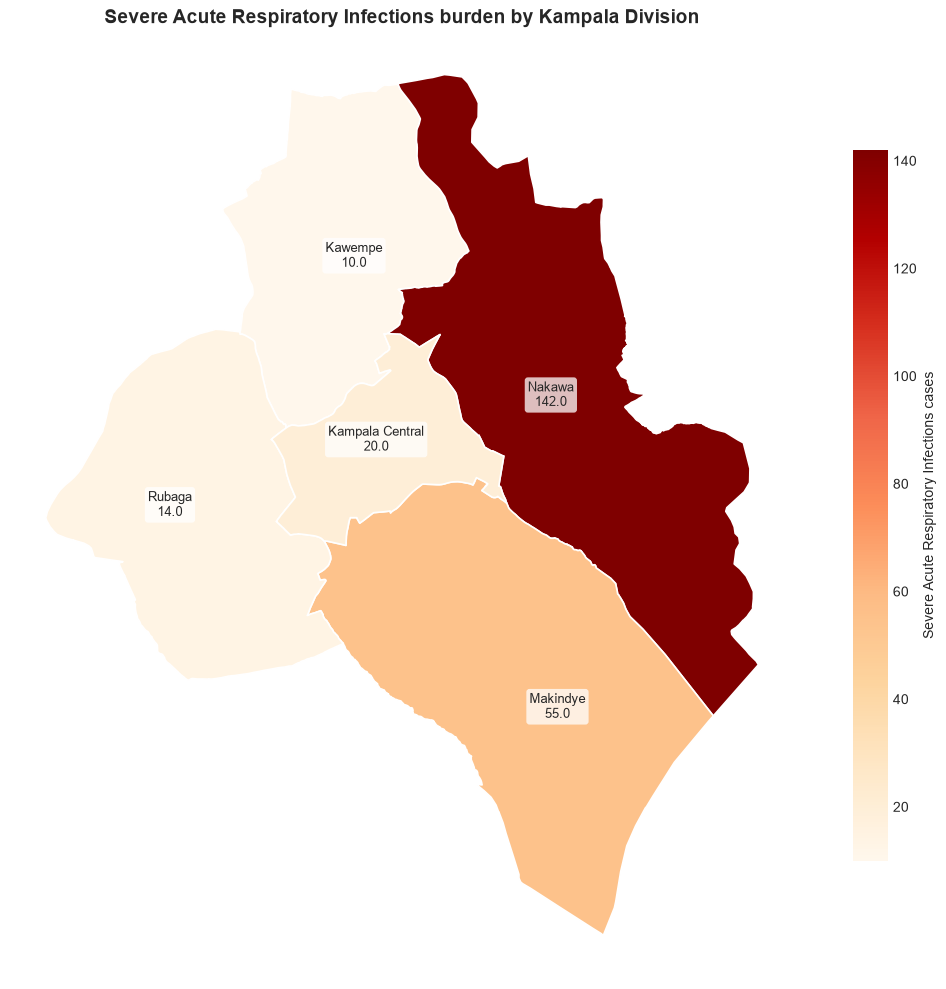

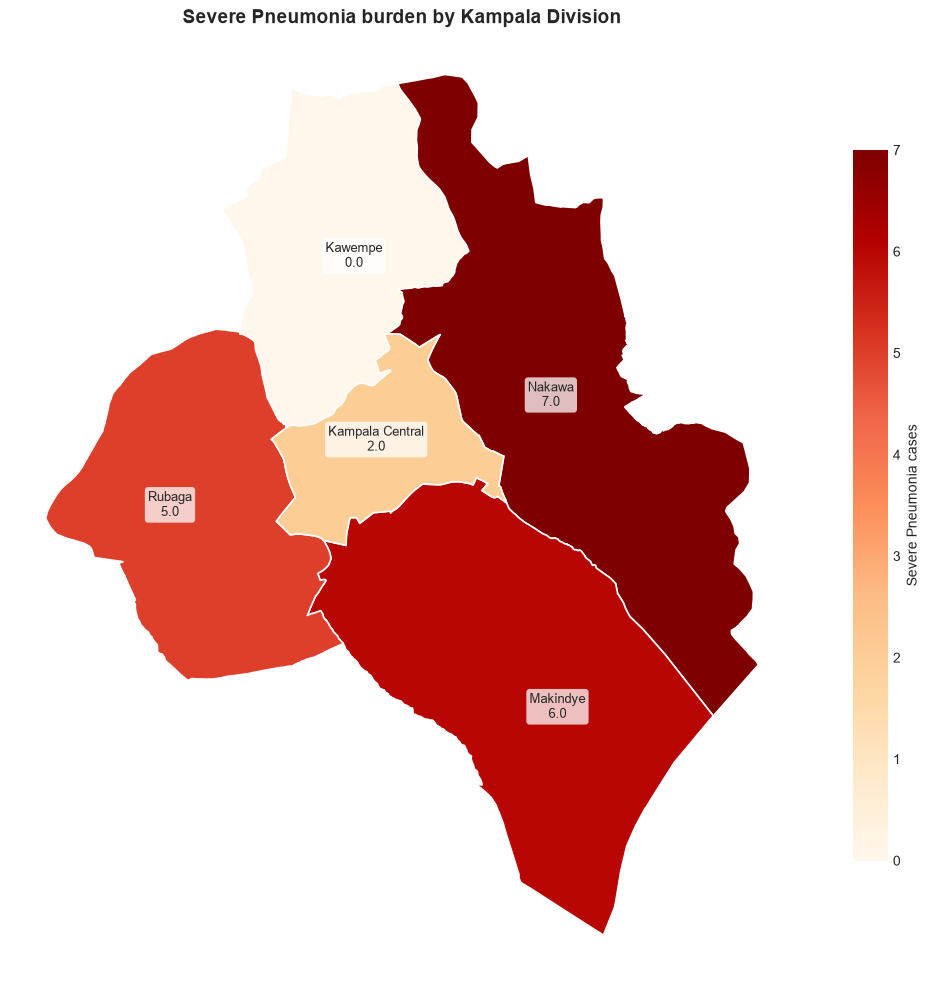

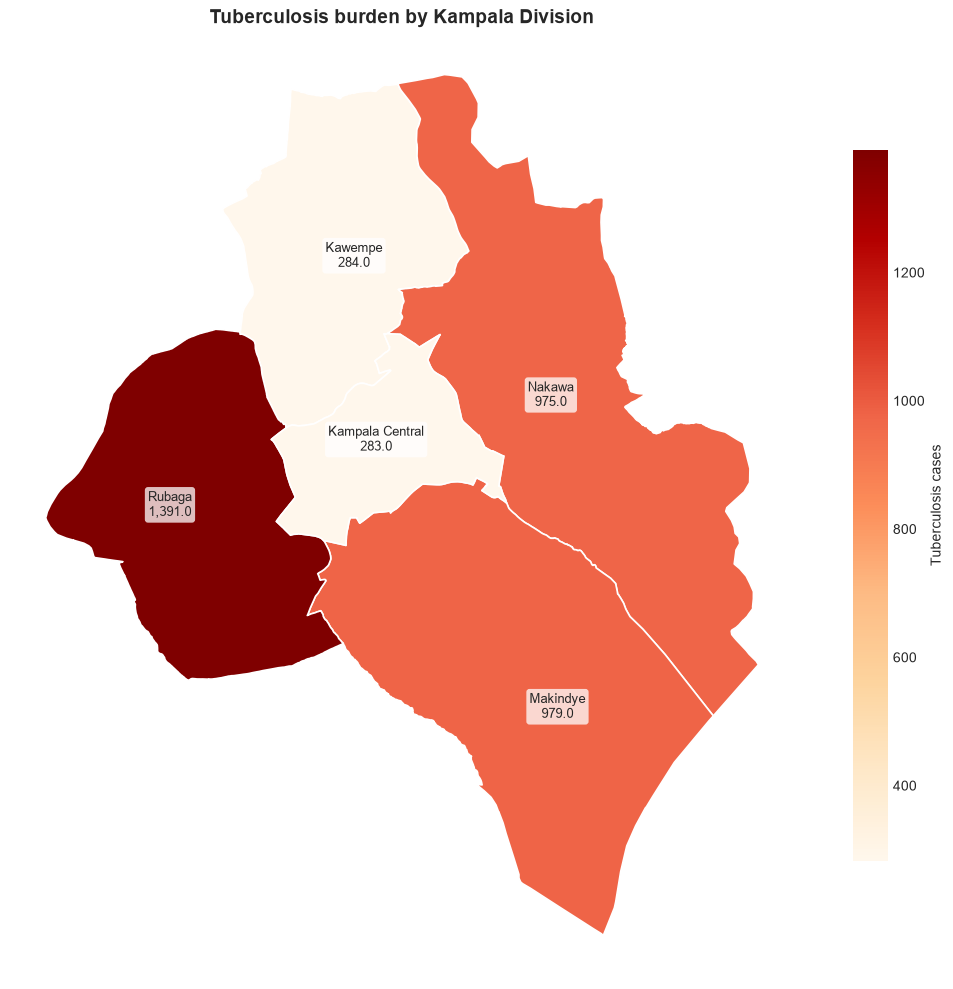

,division,mean_pm25,median_pm25,sensor_sites,monitoring_records,total_respiratory_cases,unique_parishes,disease__Influenza Like Illness,disease__Pneumonia,disease__Severe Acute Respiratory Infections,disease__Severe Pneumonia,disease__Tuberculosis
3,Rubaga,54.334055,47.73570,1,24877,1905,171,377,118,14,5,1391
2,Makindye,42.694804,33.44750,2,53377,1108,157,13,55,55,6,979
0,Kawempe,41.058471,31.79715,3,81720,351,76,47,10,10,0,284
4,Kampala Central,36.725346,30.46185,1,13214,321,71,1,15,20,2,283
1,Nakawa,32.264413,25.41410,2,40520,1338,114,6,208,142,7,975


In [19]:
## Population denominators and enhanced spatial analysis
# Recorded facility cases are converted to rates using Kampala division population
# denominators. Parish linkage is auditable; unmatched parishes are never assigned.
import importlib
import src.kampala_health_analysis as kampala_health_analysis
importlib.reload(kampala_health_analysis)
from src.kampala_health_analysis import (
    build_spatial_panel, demographic_spatial_summary, diagnosis_population_rate_summary,
    fit_case_mix_model, fit_spatial_rate_models, load_medical_records, load_population,
    parish_linkage_summary, plot_demographic_rate_heatmap,
    plot_division_map as plot_enhanced_division_map, plot_exposure_response,
    plot_medical_record_flow, population_denominator_summary, spatial_summary,
)

population_by_parish = load_population()
division_population_denominators = population_denominator_summary(population_by_parish)
display(division_population_denominators)

spatial_rate_panel, medical_records, spatial_quality = build_spatial_panel(frequency='W-SUN')
enhanced_spatial_summary = spatial_summary(spatial_rate_panel, medical_records)
spatial_demographic_summary = demographic_spatial_summary(spatial_rate_panel)
diagnosis_population_rates = diagnosis_population_rate_summary(medical_records, population_by_parish)
spatial_rate_models = fit_spatial_rate_models(spatial_rate_panel)
case_mix_models = fit_case_mix_model(medical_records)

print('Interpret rates and model estimates as associations with recorded facility cases, not population incidence.')
print('Parish results remain descriptive unless the crosswalk and boundary checks are approved.')
display(
    spatial_quality,
    enhanced_spatial_summary,
    diagnosis_population_rates,
    spatial_demographic_summary.head(20),
    parish_linkage_summary(medical_records).head(20),
    spatial_rate_models,
    case_mix_models,
)
plot_enhanced_division_map(enhanced_spatial_summary, 'mean_pm25', 'Mean PM2.5 by Kampala division, 2020-2024', legend_label='Mean PM2.5 (µg/m³)')
plot_enhanced_division_map(enhanced_spatial_summary, 'mean_rate_per_100k', 'Weekly, excluding death outcomes recorded RTI rate per 100,000 by division', legend_label='Recorded rate per 100,000')

# One labelled, population-standardised division map for every diagnosis.
for diagnosis, diagnosis_rates in diagnosis_population_rates.groupby('diagnosis', sort=True):
    plot_enhanced_division_map(
        diagnosis_rates,
        'annualized_recorded_rate_per_100k',
        f'{diagnosis}: annualised recorded-case rate by division',
        legend_label='Annualised recorded cases per 100,000',
    )

plot_medical_record_flow(load_medical_records())
plot_demographic_rate_heatmap(spatial_rate_panel)
plot_exposure_response(spatial_rate_panel)
plt.show()

# Spatial analysis: PM2.5 and burden for every recorded respiratory diagnosis
try:
    import geopandas as gpd
except ImportError as exc:
    raise ImportError('Spatial analysis requires geopandas in the active notebook environment.') from exc
from pathlib import Path

def standardize_division(value):
    if pd.isna(value):
        return np.nan
    mapping = {
        'kampala central': 'Kampala Central', 'central division': 'Kampala Central', 'central': 'Kampala Central',
        'kawempe': 'Kawempe', 'kawempe division': 'Kawempe', 'nakawa': 'Nakawa', 'nakawa division': 'Nakawa',
        'makindye': 'Makindye', 'makindye division': 'Makindye', 'rubaga': 'Rubaga',
        'rubaga division': 'Rubaga', 'lubaga': 'Rubaga', 'lubaga division': 'Rubaga',
    }
    return mapping.get(str(value).strip().lower(), str(value).strip().title())

base_path = Path('data')
shapefile_path = base_path / 'Kampala Shapefile' / 'KMA Subcounties.shp'
air_quality_paths = [base_path / 'bq-results-20260322-100500-1774173924222.csv', base_path / 'bq-results-20260322-100723-1774174052683.csv']
health_path = base_path / 'Exploring_the_Association_Between_Air_Quality_and_the_Burden_of_Respiratory_Tract_Infections_in_Greater_Kampala_Uganda_-_all_versions_-_labels_-_2026-06-23-13-15-43.xlsx'
kampala_order = ['Kampala Central', 'Kawempe', 'Makindye', 'Nakawa', 'Rubaga']
kampala_map = gpd.read_file(shapefile_path)
kampala_map['division'] = kampala_map['sname2019'].apply(standardize_division)
kampala_map = kampala_map[kampala_map['division'].isin(kampala_order)].drop_duplicates('division').copy()

air_spatial = pd.concat([pd.read_csv(path, usecols=['timestamp', 'site_id', 'site_name', 'pm2_5_calibrated_value', 'parish']) for path in air_quality_paths], ignore_index=True).drop_duplicates(subset=['timestamp', 'site_id'])
air_spatial['division'] = air_spatial['site_name'].str.split(',').str[-1].str.strip().apply(standardize_division)
air_spatial.loc[air_spatial['parish'].astype(str).str.contains('makindye division', case=False, na=False), 'division'] = 'Makindye'
air_spatial = air_spatial[air_spatial['division'].isin(kampala_order)]
division_pm25 = air_spatial.groupby('division', as_index=False).agg(mean_pm25=('pm2_5_calibrated_value', 'mean'), median_pm25=('pm2_5_calibrated_value', 'median'), monitoring_records=('pm2_5_calibrated_value', 'size'), sensor_sites=('site_id', 'nunique'))

health_spatial = pd.read_excel(health_path)
health_spatial['division'] = health_spatial['10. Division (Kampala)'].apply(standardize_division)
health_spatial['diagnosis'] = health_spatial['3. Patient Diagnosis'].fillna('Unknown').astype(str).str.strip()
health_spatial = health_spatial[health_spatial['division'].isin(kampala_order)]
diagnosis_burden = health_spatial.groupby(['division', 'diagnosis']).size().unstack(fill_value=0)
diagnosis_burden.columns = [f'disease__{name}' for name in diagnosis_burden.columns]
spatial_summary = kampala_map[['division', 'geometry']].merge(division_pm25, on='division', how='left').merge(diagnosis_burden.reset_index(), on='division', how='left')
burden_columns = [col for col in spatial_summary.columns if col.startswith('disease__')]
for col in ['mean_pm25', 'median_pm25', 'monitoring_records', 'sensor_sites', *burden_columns]:
    spatial_summary[col] = spatial_summary[col].fillna(0)
spatial_summary['total_respiratory_cases'] = spatial_summary[burden_columns].sum(axis=1)
spatial_summary['unique_parishes'] = spatial_summary['division'].map(health_spatial.groupby('division')['12. Parish name:'].nunique()).fillna(0)

def plot_division_map(frame, column, title, label):
    fig, ax = plt.subplots(figsize=(12, 10))
    frame.plot(column=column, cmap='OrRd', linewidth=1.2, edgecolor='white', legend=True, ax=ax, legend_kwds={'label': label, 'shrink': 0.75})
    for point, division, value in zip(frame.geometry.representative_point(), frame['division'], frame[column]):
        ax.annotate(f'{division}\n{value:,.1f}', (point.x, point.y), ha='center', va='center', fontsize=9, bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.75))
    ax.set_title(title, fontsize=14, fontweight='bold'); ax.set_axis_off(); plt.tight_layout(); plt.show()

plot_division_map(spatial_summary, 'mean_pm25', 'Average PM2.5 by Kampala Division', 'Average PM2.5 (μg/m³)')
for burden_column in burden_columns:
    disease_name = burden_column.removeprefix('disease__')
    plot_division_map(spatial_summary, burden_column, f'{disease_name} burden by Kampala Division', f'{disease_name} cases')
spatial_summary_table = spatial_summary[['division', 'mean_pm25', 'median_pm25', 'sensor_sites', 'monitoring_records', 'total_respiratory_cases', 'unique_parishes', *burden_columns]].sort_values('mean_pm25', ascending=False)
spatial_summary_table


## Step 4: Time Series Modeling


### 7. Sensitivity analyses

The sensitivity table compares the primary PM₂.₅ estimate with alternatives that exclude high-PM₂.₅ observations and use a lagged exposure. Consistency in direction and magnitude strengthens robustness; discrepancies should be reported rather than reconciled post hoc.


In [20]:
# Sensitivity analyses for every disease
sensitivity_specs = [('Primary adjusted model', processed_data.copy()), ('Exclude highest 5% PM2.5', processed_data[processed_data['pm2_5'] <= processed_data['pm2_5'].quantile(.95)].copy())]
lagged = processed_data.copy(); lagged['pm2_5'] = lagged['pm2_5'].shift(1); sensitivity_specs.append(('One-period lagged PM2.5', lagged))
sensitivity_results = []
for disease in disease_columns:
    for label, frame in sensitivity_specs:
        result = poisson_pm25_model(frame, disease, None)
        if result is not None: result.update({'Disease': disease, 'Specification': label}); sensitivity_results.append(result)
sensitivity_results = pd.DataFrame(sensitivity_results)
display(sensitivity_results[['Disease', 'Specification', 'N', 'IRR per 10 µg/m³', '95% CI lower', '95% CI upper', 'p-value']].round(3))


,Disease,Specification,N,IRR per 10 µg/m³,95% CI lower,95% CI upper,p-value
0,TB,Primary adjusted model,248,0.952,0.924,0.981,0.001
1,TB,Exclude highest 5% PM2.5,235,0.967,0.941,0.994,0.018
2,TB,One-period lagged PM2.5,247,0.978,0.955,1.002,0.075
3,ILI,Primary adjusted model,248,1.173,1.030,1.335,0.016
4,ILI,Exclude highest 5% PM2.5,235,1.171,1.023,1.341,0.022
5,ILI,One-period lagged PM2.5,247,1.171,1.020,1.344,0.025
6,pneumonia_u5,Primary adjusted model,248,0.956,0.908,1.005,0.080
7,pneumonia_u5,Exclude highest 5% PM2.5,235,0.981,0.915,1.051,0.587
8,pneumonia_u5,One-period lagged PM2.5,247,0.961,0.904,1.022,0.207
9,SARI,Primary adjusted model,248,1.038,0.950,1.135,0.410


### 4.1 Interrupted Time Series


#### 4.1.1 ITS Preparation and Counterfactual Estimation


In [21]:
# --- 1. Data Preprocessing ---
data_itsa = processed_data.copy()
date_source = processed_data['date'] if 'date' in processed_data.columns else processed_data['ds']
data_itsa['date'] = pd.to_datetime(date_source, errors='coerce', dayfirst=True)
data_itsa = data_itsa.dropna(subset=['date']).sort_values('date').set_index('date')


In [22]:
# Prepare all disease outcomes and environmental variables for interrupted time-series analysis
disease_columns = [col for col in ['TB', 'ILI', 'pneumonia_u5', 'SARI'] if col in data_itsa.columns]
its_numeric_cols = [col for col in [*disease_columns, 'pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip'] if col in data_itsa.columns]
data_itsa[its_numeric_cols] = data_itsa[its_numeric_cols].apply(pd.to_numeric, errors='coerce')
data_itsa[its_numeric_cols] = data_itsa[its_numeric_cols].interpolate(limit_direction='both').ffill().bfill()
print(f'Prepared ITS data for {len(disease_columns)} disease outcomes and {len(its_numeric_cols)} numeric variables.')


Prepared ITS data for 4 disease outcomes and 9 numeric variables.


In [23]:
# --- 3. Define the Intervention Point ---
intervention_point = len(data_itsa) // 2
intervention_date = data_itsa.index[intervention_point]

print(f"\nThe dataset has {len(data_itsa)} data points.")
print(f"The intervention is set at index {intervention_point}, which corresponds to the date: {intervention_date.date()}")



The dataset has 248 data points.
The intervention is set at index 124, which corresponds to the date: 2022-05-29


In [24]:
# --- 4. Create Interrupted Time Series (ITS) Variables ---
data_itsa['time'] = np.arange(1, len(data_itsa) + 1)
data_itsa['intervention'] = (data_itsa.index >= intervention_date).astype(int)

data_itsa['time_since_intervention'] = 0
post_intervention_indices = data_itsa[data_itsa['intervention'] == 1].index
time_since_intervention_values = np.arange(len(post_intervention_indices))
data_itsa.loc[post_intervention_indices, 'time_since_intervention'] = time_since_intervention_values


In [25]:
# LSTM intervention-trend models for every disease outcome
disease_cols = [col for col in ['TB', 'ILI', 'pneumonia_u5', 'SARI'] if col in data_itsa.columns]
base_feature_cols = [col for col in ['pm2_5', 'avgtemp', 'avghumidity', 'avgtemp_sat', 'humidity_sat', 'windspeed', 'precip', 'time', 'intervention', 'time_since_intervention'] if col in data_itsa.columns]
sequence_length = 8
lstm_performance = []
for disease in disease_cols:
    model_df = data_itsa[base_feature_cols + [disease]].dropna(subset=[disease]).copy().fillna(0)
    if len(model_df) <= sequence_length + 2:
        continue
    feature_scaler, target_scaler = MinMaxScaler(), MinMaxScaler()
    scaled_features = feature_scaler.fit_transform(model_df[base_feature_cols])
    scaled_target = target_scaler.fit_transform(model_df[[disease]])
    X_all = np.array([scaled_features[i-sequence_length:i] for i in range(sequence_length, len(model_df))])
    y_all = scaled_target[sequence_length:]
    train_size = max(2, int(len(X_all) * 0.8))
    model = Sequential([LSTM(32, input_shape=(sequence_length, X_all.shape[2])), Dropout(0.2), Dense(16, activation='relu'), Dense(1)])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_all[:train_size], y_all[:train_size], epochs=150, batch_size=16, validation_split=0.2, verbose=0, callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])
    predicted = target_scaler.inverse_transform(model.predict(X_all, verbose=0)).flatten()
    prediction_column = f'predicted_{disease}'
    data_itsa[prediction_column] = data_itsa[disease].astype(float)
    data_itsa.loc[model_df.index[sequence_length:], prediction_column] = predicted
    actual = model_df[disease].iloc[sequence_length:]
    lstm_performance.append({'Disease': disease, 'RMSE': np.sqrt(mean_squared_error(actual, predicted)), 'MAE': mean_absolute_error(actual, predicted), 'Training windows': train_size})
lstm_performance = pd.DataFrame(lstm_performance)
lstm_performance


,Disease,RMSE,MAE,Training windows
0,TB,132.480888,97.720498,192
1,ILI,784.420221,353.463356,192
2,pneumonia_u5,73.745174,36.597404,192
3,SARI,159.711598,97.896393,192


### 4.2 Overall ITS Analysis of TB Cases


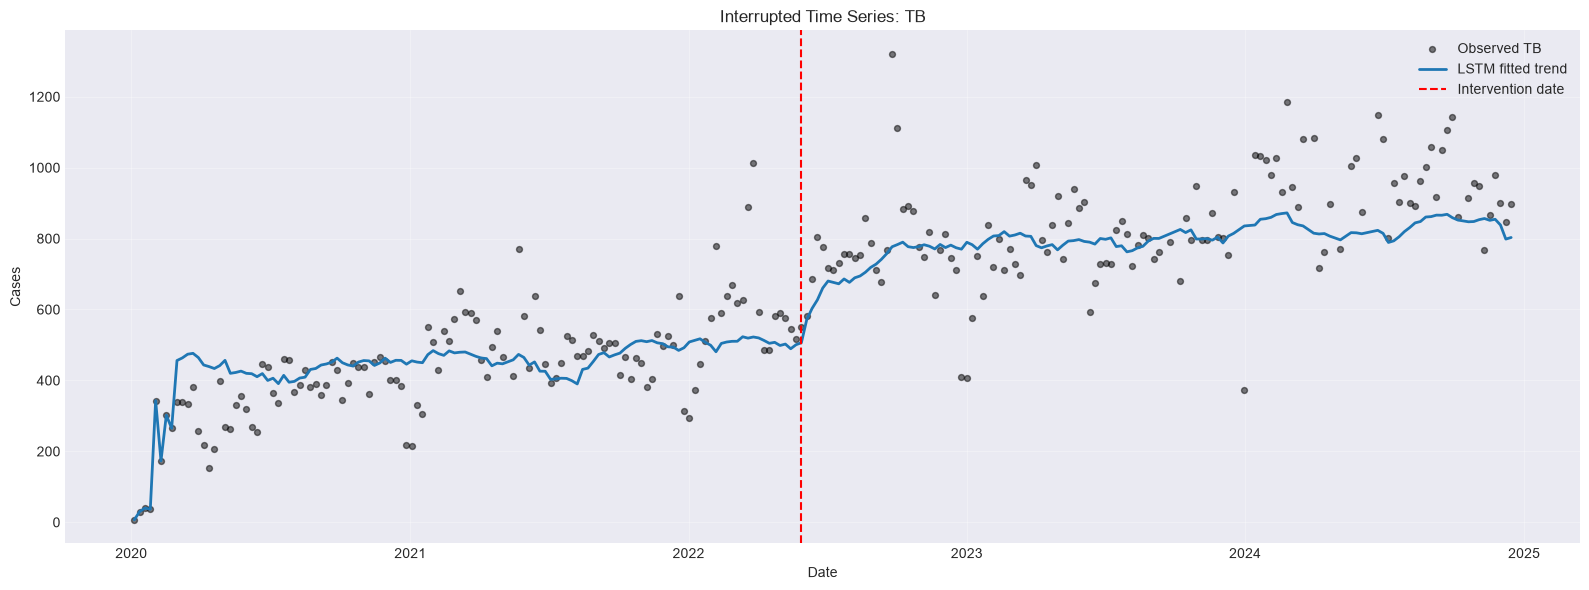

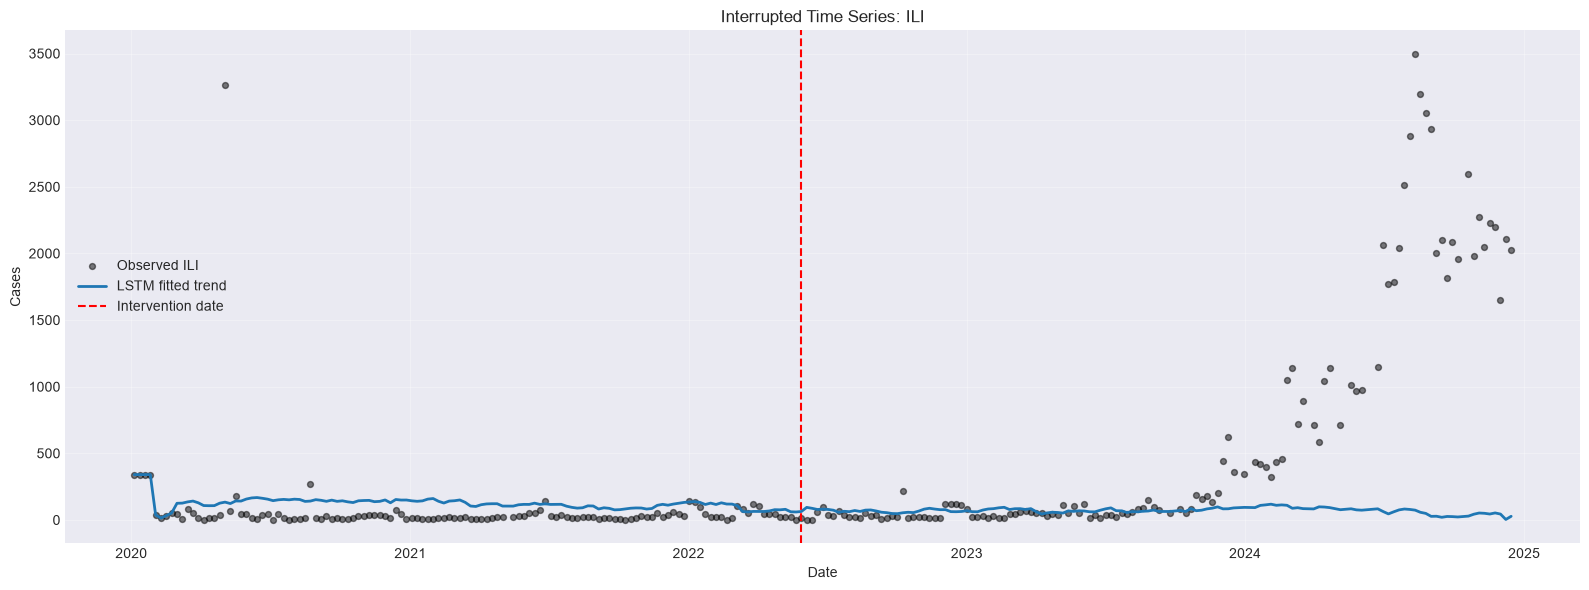

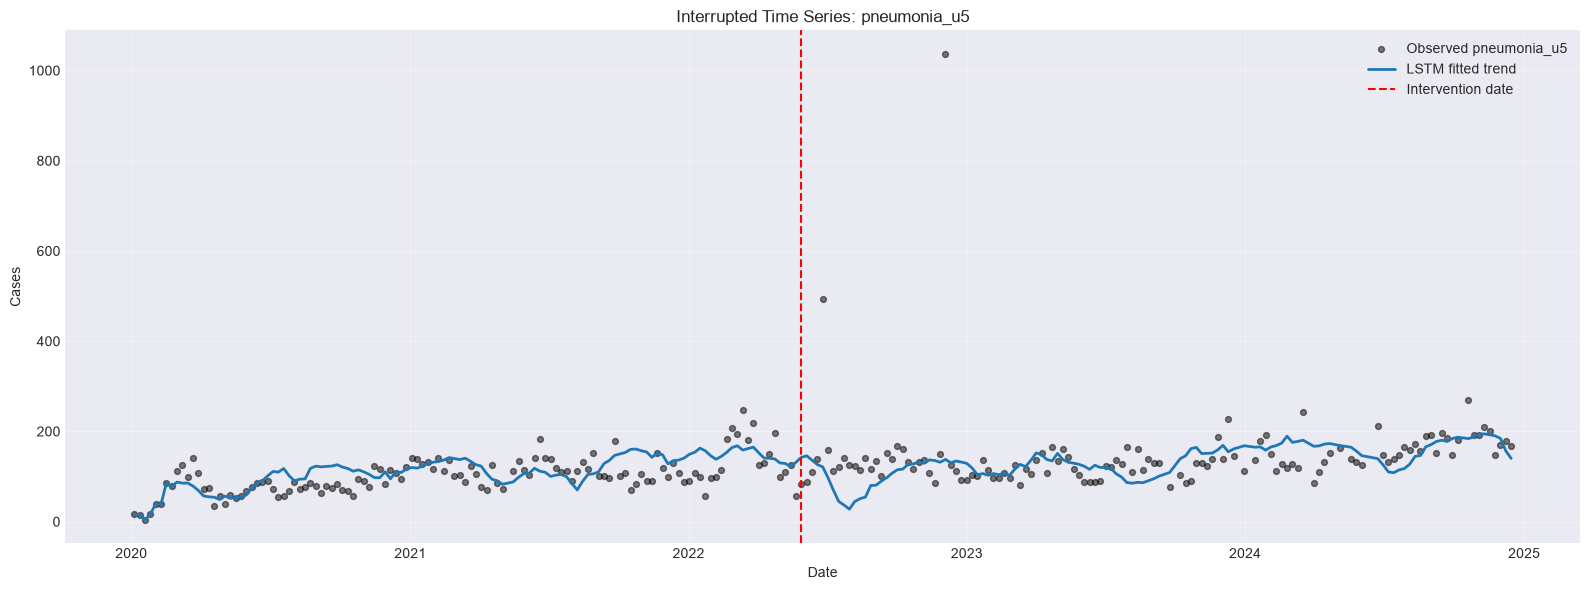

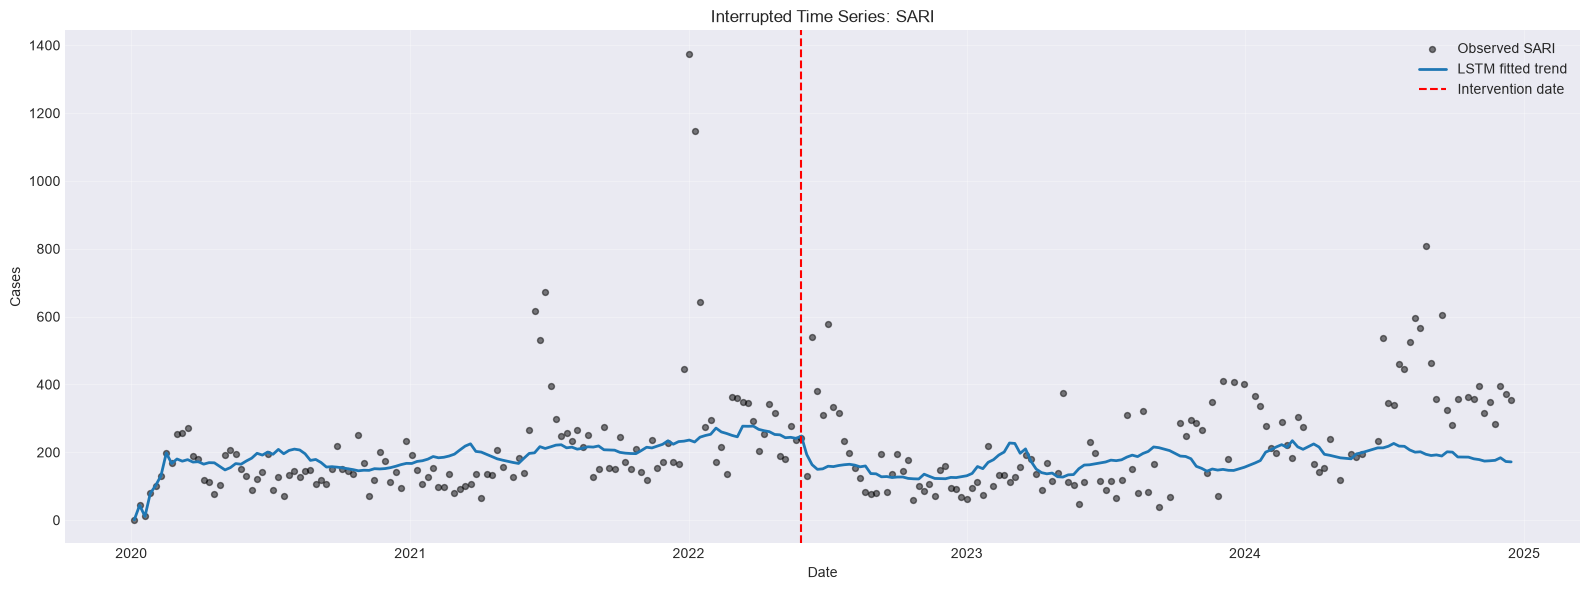

In [26]:
# Observed and LSTM-predicted trends for every disease
for disease in disease_cols:
    prediction_column = f'predicted_{disease}'
    if prediction_column not in data_itsa.columns:
        continue
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.scatter(data_itsa.index, data_itsa[disease], color='black', alpha=0.5, label=f'Observed {disease}', s=18)
    ax.plot(data_itsa.index, data_itsa[prediction_column], color='tab:blue', linewidth=2, label='LSTM fitted trend')
    ax.axvline(intervention_date, color='red', linestyle='--', label='Intervention date')
    ax.set(title=f'Interrupted Time Series: {disease}', xlabel='Date', ylabel='Cases'); ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


### 4.3 TensorFlow Forecast Preparation


In [27]:
data_project = processed_data.copy()
if 'date' in data_project.columns:
    data_project['ds'] = pd.to_datetime(data_project['date'], errors='coerce', dayfirst=True)
else:
    data_project['ds'] = pd.to_datetime(data_project['ds'], errors='coerce', dayfirst=True)

disease_cols = [col for col in ['TB', 'ILI', 'pneumonia_u5', 'SARI'] if col in data_project.columns]
data_project = data_project.sort_values('ds').reset_index(drop=True)

if 'county' not in data_project.columns:
    data_project['county'] = 'Kampala'
data_project['year_month'] = data_project['ds'].dt.to_period('M').astype(str)

if 'month' not in data_project.columns:
    data_project['month'] = data_project['ds'].dt.month
if 'week_of_year' not in data_project.columns:
    data_project['week_of_year'] = data_project['ds'].dt.isocalendar().week.astype(int)
if 'quarter' not in data_project.columns:
    data_project['quarter'] = data_project['ds'].dt.quarter
if 'day_of_year' not in data_project.columns:
    data_project['day_of_year'] = data_project['ds'].dt.dayofyear
if 'is_weekend' not in data_project.columns:
    data_project['is_weekend'] = data_project['ds'].dt.dayofweek.isin([5, 6]).astype(int)

if 'time' not in data_project.columns:
    data_project['time'] = np.arange(1, len(data_project) + 1)

if 'intervention' not in data_project.columns or 'time_since_intervention' not in data_project.columns:
    intervention_point = len(data_project) // 2
    intervention_date = data_project.loc[intervention_point, 'ds']
    data_project['intervention'] = (data_project['ds'] >= intervention_date).astype(int)
    data_project['time_since_intervention'] = np.where(
        data_project['intervention'] == 1,
        np.arange(len(data_project)) - intervention_point,
        0
    )
else:
    intervention_date = data_project.loc[data_project['intervention'].eq(1), 'ds'].min()

print(f"Using {len(disease_cols)} diseases for downstream TensorFlow modeling:")
print(disease_cols)
print(f"Intervention date reference: {pd.to_datetime(intervention_date).date()}")


Using 4 diseases for downstream TensorFlow modeling:
['TB', 'ILI', 'pneumonia_u5', 'SARI']
Intervention date reference: 2022-05-29


### 4.4 TensorFlow Fusion Forecast Helpers


In [ ]:
sequence_length = 8

base_sequence_candidates = [
    'pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip',
    'avgtemp_sat', 'humidity_sat', 'temp_humidity_interaction',
    'windspeed_rolling_4', 'pm25_temp_ratio', 'pm25_humidity_ratio',
    'pm25_trailing_ma_7', 'pm25_trailing_ma_14',
    'pm25_trailing_ma_30', ]
base_dense_candidates = [
    'time', 'intervention', 'time_since_intervention', 'month',
    'week_of_year', 'quarter', 'day_of_year', 'is_weekend',
    'pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip',
    'precip_rolling_4', 'windspeed_rolling_4', 'pm25_temp_ratio',
    'pm25_humidity_ratio', 'pm25_trailing_ma_7',
    'pm25_trailing_ma_14', 'pm25_trailing_ma_30',
]

benchmark_feature_candidates = [
    'pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip',
    'precip_rolling_4', 'windspeed_rolling_4', 'pm25_temp_ratio',
    'pm25_humidity_ratio', 'pm25_trailing_ma_7',
    'pm25_trailing_ma_14', 'pm25_trailing_ma_30',
]


def build_target_features(frame, disease):
    target_frame = frame.copy()
    lag_cols = []
    ma_cols = []
    for lag in [1, 2, 3, 4]:
        col = f'{disease}_lag_{lag}'
        target_frame[col] = target_frame[disease].shift(lag)
        lag_cols.append(col)
    for window in [4, 8]:
        trailing_col = f'{disease}_trailing_ma_{window}'
        target_frame[trailing_col] = target_frame[disease].rolling(window=window, min_periods=1).mean()
        ma_cols.append(trailing_col)
        target_frame[leading_col] = target_frame[disease].iloc[::-1].rolling(window=window, min_periods=1).mean().iloc[::-1]
        ma_cols.append(leading_col)
    diff_col = f'{disease}_diff_1'
    pct_col = f'{disease}_pct_change_1'
    target_frame[diff_col] = target_frame[disease].diff()
    target_frame[pct_col] = target_frame[disease].pct_change().replace([np.inf, -np.inf], np.nan)
    return target_frame, lag_cols, ma_cols, diff_col, pct_col


def create_fusion_arrays(frame, sequence_cols, dense_cols, target_col, seq_len):
    X_seq, X_dense, y, dates = [], [], [], []
    for idx in range(seq_len, len(frame)):
        X_seq.append(frame.loc[idx - seq_len:idx - 1, sequence_cols].to_numpy(dtype=float))
        X_dense.append(frame.loc[idx, dense_cols].to_numpy(dtype=float))
        y.append(float(frame.loc[idx, target_col]))
        dates.append(frame.loc[idx, 'ds'])
    return np.asarray(X_seq), np.asarray(X_dense), np.asarray(y), pd.to_datetime(dates)


def build_fusion_model(seq_shape, dense_dim):
    sequence_input = Input(shape=seq_shape, name='sequence_input')
    sequence_branch = LSTM(32, dropout=0.1, name='sequence_lstm')(sequence_input)
    sequence_branch = Dense(16, activation='relu', name='sequence_dense')(sequence_branch)

    dense_input = Input(shape=(dense_dim,), name='dense_input')
    dense_branch = Dense(16, activation='relu', name='dense_dense')(dense_input)
    dense_branch = Dropout(0.1, name='dense_dropout')(dense_branch)

    fused = Concatenate(name='fusion_concat')([sequence_branch, dense_branch])
    fused = Dense(16, activation='relu', name='fusion_dense')(fused)
    output = Dense(1, name='prediction')(fused)

    model = Model(inputs=[sequence_input, dense_input], outputs=output, name='fusion_lstm_regressor')
    model.compile(optimizer='adam', loss='mse')
    return model


def train_disease_fusion_model(frame, disease, seq_len=8, test_fraction=0.2):
    target_frame, lag_cols, ma_cols, diff_col, pct_col = build_target_features(frame, disease)

    sequence_cols = [col for col in base_sequence_candidates if col in target_frame.columns]
    sequence_cols += [col for col in lag_cols + ma_cols if col in target_frame.columns]

    dense_cols = [col for col in base_dense_candidates if col in target_frame.columns]
    dense_cols += [col for col in [diff_col, pct_col] if col in target_frame.columns]

    needed_cols = ['ds', disease] + sequence_cols + dense_cols
    model_frame = target_frame[needed_cols].copy().replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

    if len(model_frame) <= seq_len + 10:
        raise ValueError(f'Not enough usable rows for {disease} after feature engineering.')

    X_seq_raw, X_dense_raw, y_raw, dates = create_fusion_arrays(
        model_frame,
        sequence_cols=sequence_cols,
        dense_cols=dense_cols,
        target_col=disease,
        seq_len=seq_len
    )

    total_samples = len(y_raw)
    split_idx = max(8, int(total_samples * (1 - test_fraction)))
    split_idx = min(split_idx, total_samples - 2)
    if split_idx <= 1:
        raise ValueError(f'Not enough train/test samples for {disease}.')

    X_seq_train_raw = X_seq_raw[:split_idx]
    X_seq_test_raw = X_seq_raw[split_idx:]
    X_dense_train_raw = X_dense_raw[:split_idx]
    X_dense_test_raw = X_dense_raw[split_idx:]
    y_train_raw = y_raw[:split_idx]
    y_test_raw = y_raw[split_idx:]

    sequence_scaler = MinMaxScaler()
    dense_scaler = StandardScaler()
    target_scaler = MinMaxScaler()

    sequence_scaler.fit(X_seq_train_raw.reshape(-1, X_seq_train_raw.shape[-1]))
    dense_scaler.fit(X_dense_train_raw)
    target_scaler.fit(y_train_raw.reshape(-1, 1))

    def scale_sequence(values):
        scaled = sequence_scaler.transform(values.reshape(-1, values.shape[-1]))
        return scaled.reshape(values.shape)

    X_seq_train = scale_sequence(X_seq_train_raw)
    X_seq_test = scale_sequence(X_seq_test_raw)
    X_dense_train = dense_scaler.transform(X_dense_train_raw)
    X_dense_test = dense_scaler.transform(X_dense_test_raw)
    y_train = target_scaler.transform(y_train_raw.reshape(-1, 1))

    model = build_fusion_model((seq_len, X_seq_train.shape[-1]), X_dense_train.shape[-1])
    callbacks = [EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)]
    history = model.fit(
        [X_seq_train, X_dense_train],
        y_train,
        epochs=40,
        batch_size=min(16, max(4, len(X_seq_train))),
        validation_split=0.2 if len(X_seq_train) >= 12 else 0.0,
        verbose=0,
        callbacks=callbacks if len(X_seq_train) >= 12 else []
    )

    y_train_pred = target_scaler.inverse_transform(
        model.predict([X_seq_train, X_dense_train], verbose=0)
    ).flatten()
    y_test_pred = target_scaler.inverse_transform(
        model.predict([X_seq_test, X_dense_test], verbose=0)
    ).flatten()

    train_residual_std = float(np.std(y_train_raw - y_train_pred)) if len(y_train_raw) > 1 else 0.0
    all_predictions = np.concatenate([y_train_pred, y_test_pred])

    metrics = {
        'Disease': disease,
        'Model': 'TensorFlow Fusion LSTM + Dense',
        'MAE': mean_absolute_error(y_test_raw, y_test_pred),
        'RMSE': mean_squared_error(y_test_raw, y_test_pred) ** 0.5,
        'R²': r2_score(y_test_raw, y_test_pred) if len(y_test_raw) > 1 else np.nan,
        'Train Samples': int(len(y_train_raw)),
        'Test Samples': int(len(y_test_raw))
    }

    prediction_frame = pd.DataFrame({
        'ds': dates,
        'actual': y_raw,
        'predicted': all_predictions,
        'lower': all_predictions - 1.96 * train_residual_std,
        'upper': all_predictions + 1.96 * train_residual_std,
        'dataset_split': ['Train' if idx < split_idx else 'Test' for idx in range(total_samples)]
    })

    return {
        'metrics': metrics,
        'history': history.history,
        'prediction_frame': prediction_frame,
        'sequence_cols': sequence_cols,
        'dense_cols': dense_cols
    }


def run_benchmark_models(frame, disease):
    benchmark_frame, lag_cols, ma_cols, diff_col, pct_col = build_target_features(frame, disease)
    benchmark_features = [col for col in benchmark_feature_candidates if col in benchmark_frame.columns]
    benchmark_features += [col for col in lag_cols + ma_cols + [diff_col, pct_col] if col in benchmark_frame.columns]

    benchmark_frame = benchmark_frame.copy().replace([np.inf, -np.inf], np.nan)
    benchmark_frame['county'] = benchmark_frame.get('county', 'Kampala')
    benchmark_frame['year_month'] = benchmark_frame['ds'].dt.to_period('M').astype(str)

    ts_modeler = TimeSeriesModeler(benchmark_frame, target_column=disease)
    X_ts, y_ts = ts_modeler.prepare_time_series_data(
        window_size=sequence_length,
        features=benchmark_features,
        target_type='binary'
    )

    if len(X_ts) == 0 or len(y_ts) == 0:
        raise ValueError(f'No usable benchmark windows for {disease}.')

    benchmark_results = ts_modeler.train_models(
        X_ts,
        y_ts,
        models_to_train=['random_forest', 'gradient_boosting', 'svm'],
        cv_splits=3
    )

    if not benchmark_results:
        raise ValueError(f'No benchmark models trained for {disease}.')

    best_model_name = max(benchmark_results, key=lambda name: benchmark_results[name]['avg_f1'])
    best_metrics = benchmark_results[best_model_name]
    return {
        'Disease': disease,
        'Best Benchmark Model': best_model_name,
        'Benchmark Accuracy': best_metrics.get('avg_accuracy', np.nan),
        'Benchmark F1': best_metrics.get('avg_f1', np.nan),
        'Benchmark Precision': best_metrics.get('avg_precision', np.nan),
        'Benchmark Recall': best_metrics.get('avg_recall', np.nan)
    }


### 4.5 TensorFlow Disease Forecasts



=== Training TensorFlow fusion model for TB ===
Train samples: 188, Test samples: 48, MAE: 277.992, RMSE: 321.551, R²: -4.524


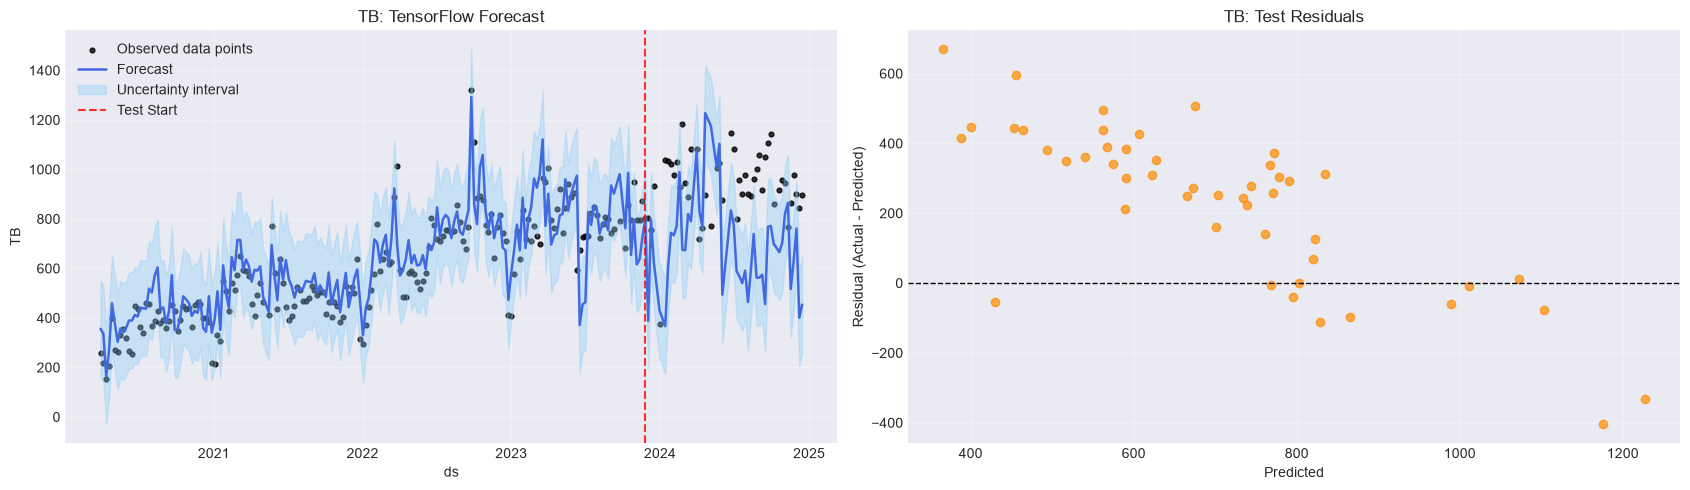

INFO:time_series_modeler:TimeSeriesModeler initialized with 248 records, target: TB
INFO:time_series_modeler:Prepared 240 samples with 192 features


=== Benchmarking classical time-series models for TB ===


INFO:time_series_modeler:Training random_forest...
INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: random_forest (F1: 0.888)



=== Training TensorFlow fusion model for ILI ===
Train samples: 188, Test samples: 48, MAE: 1389.318, RMSE: 1636.473, R²: -2.355


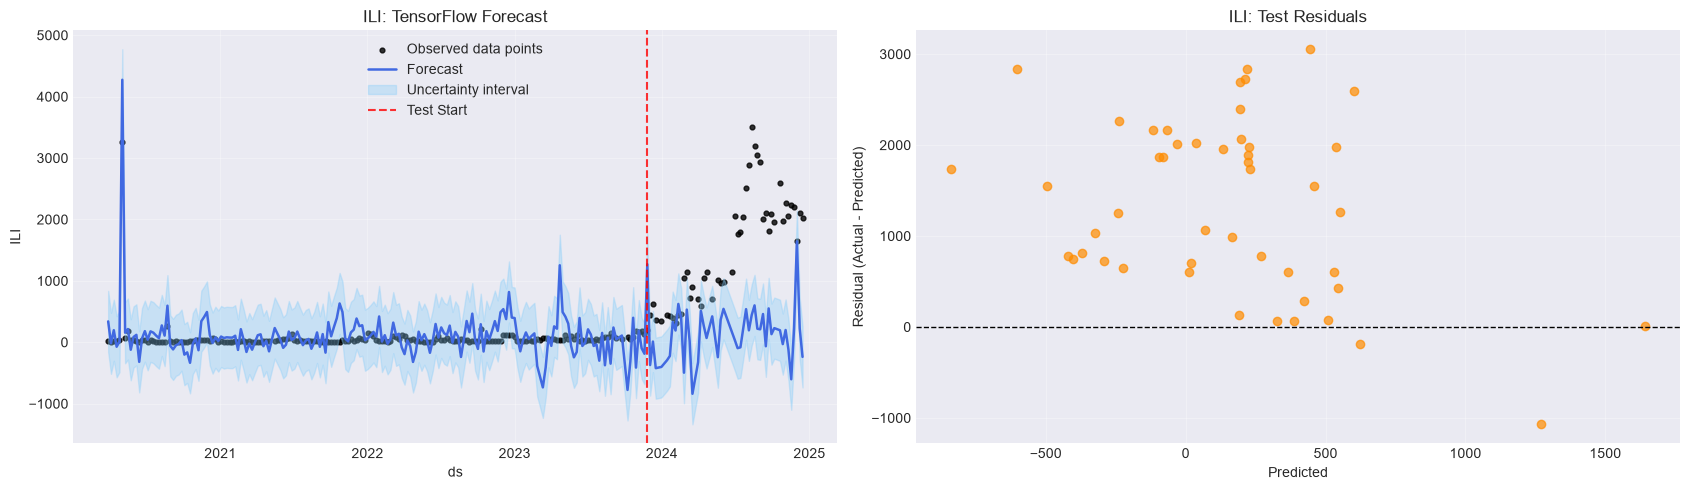

=== Benchmarking classical time-series models for ILI ===


INFO:time_series_modeler:TimeSeriesModeler initialized with 248 records, target: ILI
INFO:time_series_modeler:Prepared 240 samples with 192 features
INFO:time_series_modeler:Training random_forest...
INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: gradient_boosting (F1: 0.826)



=== Training TensorFlow fusion model for pneumonia_u5 ===
Train samples: 188, Test samples: 48, MAE: 126.353, RMSE: 161.970, R²: -18.767


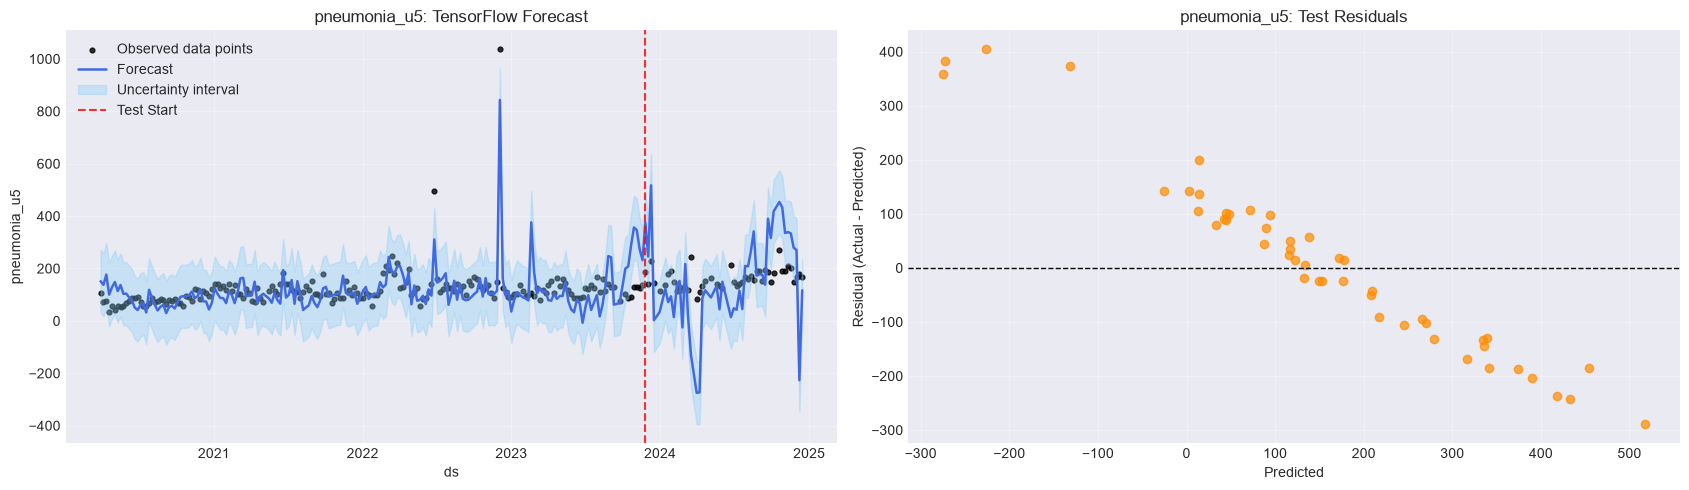

INFO:time_series_modeler:TimeSeriesModeler initialized with 248 records, target: pneumonia_u5
INFO:time_series_modeler:Prepared 240 samples with 192 features
INFO:time_series_modeler:Training random_forest...


=== Benchmarking classical time-series models for pneumonia_u5 ===


INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: random_forest (F1: 0.781)



=== Training TensorFlow fusion model for SARI ===
Train samples: 188, Test samples: 48, MAE: 283.333, RMSE: 356.099, R²: -5.259


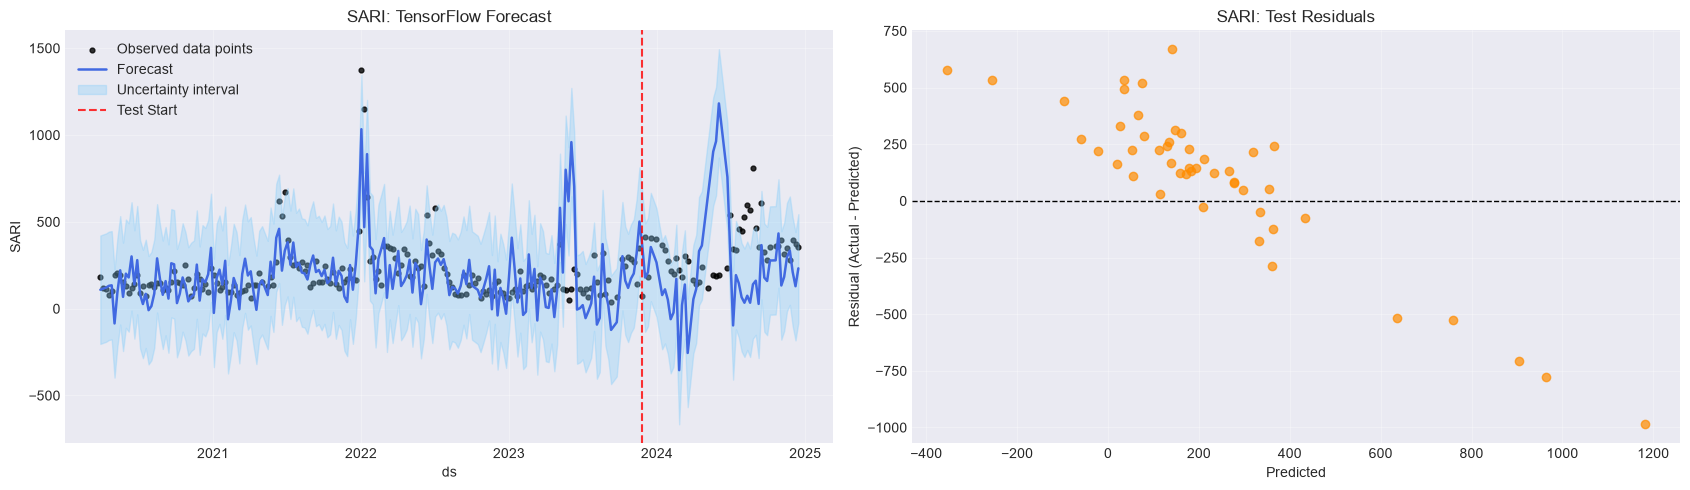

INFO:time_series_modeler:TimeSeriesModeler initialized with 248 records, target: SARI
INFO:time_series_modeler:Prepared 240 samples with 192 features
INFO:time_series_modeler:Training random_forest...


=== Benchmarking classical time-series models for SARI ===


INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: gradient_boosting (F1: 0.753)


,Disease,Model,MAE,RMSE,R²,Train Samples,Test Samples
0,pneumonia_u5,TensorFlow Fusion LSTM + Dense,126.353447,161.970168,-18.766612,188,48
1,TB,TensorFlow Fusion LSTM + Dense,277.991964,321.550949,-4.524185,188,48
2,SARI,TensorFlow Fusion LSTM + Dense,283.332630,356.099492,-5.258881,188,48
3,ILI,TensorFlow Fusion LSTM + Dense,1389.317985,1636.472705,-2.354510,188,48


In [29]:
models_performance_records = []
benchmark_records = []
disease_forecasts = {}

for disease in disease_cols:
    print(f"\n=== Training TensorFlow fusion model for {disease} ===")
    try:
        result = train_disease_fusion_model(data_project, disease, seq_len=sequence_length)
        disease_forecasts[disease] = result['prediction_frame']
        models_performance_records.append(result['metrics'])

        plot_df = result['prediction_frame']
        print(
            f"Train samples: {result['metrics']['Train Samples']}, "
            f"Test samples: {result['metrics']['Test Samples']}, "
            f"MAE: {result['metrics']['MAE']:.3f}, "
            f"RMSE: {result['metrics']['RMSE']:.3f}, "
            f"R²: {result['metrics']['R²']:.3f}"
        )

        fig, axes = plt.subplots(1, 2, figsize=(17, 5))
        axes[0].scatter(plot_df['ds'], plot_df['actual'], color='black', s=12, alpha=0.8, label='Observed data points')
        axes[0].plot(plot_df['ds'], plot_df['predicted'], color='royalblue', linewidth=1.8, label='Forecast')
        axes[0].fill_between(
            plot_df['ds'],
            plot_df['lower'],
            plot_df['upper'],
            color='lightskyblue',
            alpha=0.35,
            label='Uncertainty interval'
        )
        test_dates = plot_df.loc[plot_df['dataset_split'] == 'Test', 'ds']
        if not test_dates.empty:
            axes[0].axvline(test_dates.iloc[0], color='red', linestyle='--', alpha=0.8, label='Test Start')
        axes[0].set_title(f'{disease}: TensorFlow Forecast')
        axes[0].set_xlabel('ds')
        axes[0].set_ylabel(disease)
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        test_df = plot_df[plot_df['dataset_split'] == 'Test'].copy()
        if len(test_df) >= 2:
            residuals = test_df['actual'] - test_df['predicted']
            axes[1].scatter(test_df['predicted'], residuals, alpha=0.7, color='darkorange')
            axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
            axes[1].set_title(f'{disease}: Test Residuals')
            axes[1].set_xlabel('Predicted')
            axes[1].set_ylabel('Residual (Actual - Predicted)')
            axes[1].grid(True, alpha=0.3)
        else:
            axes[1].axis('off')
            axes[1].text(0.5, 0.5, 'Not enough test points for residual plot', ha='center', va='center')

        plt.tight_layout()
        plt.show()
    except Exception as exc:
        print(f"Skipping TensorFlow model for {disease}: {exc}")

    print(f"=== Benchmarking classical time-series models for {disease} ===")
    try:
        benchmark_records.append(run_benchmark_models(data_project, disease))
    except Exception as exc:
        print(f"Skipping benchmark models for {disease}: {exc}")

models_performance = pd.DataFrame(models_performance_records)
if not models_performance.empty:
    models_performance = models_performance.sort_values('RMSE').reset_index(drop=True)

benchmark_performance = pd.DataFrame(benchmark_records)
if not benchmark_performance.empty:
    benchmark_performance = benchmark_performance.sort_values('Benchmark F1', ascending=False).reset_index(drop=True)

models_performance


### 4.6 Model Comparison


In [30]:
print('--- TensorFlow Fusion Model Summary ---')
if not models_performance.empty:
    print(models_performance.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
    best_disease_row = models_performance.loc[models_performance['RMSE'].idxmin()]
    print(
        f"\nBest-performing disease by RMSE: {best_disease_row['Disease']} "
        f"(RMSE={best_disease_row['RMSE']:.3f}, MAE={best_disease_row['MAE']:.3f}, R²={best_disease_row['R²']:.3f})"
    )
else:
    print('No TensorFlow disease models completed successfully.')

print('\n--- Classical Time-Series Benchmark Summary ---')
if not benchmark_performance.empty:
    print(benchmark_performance.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
else:
    print('No benchmark models completed successfully.')

if not models_performance.empty and not benchmark_performance.empty:
    model_comparison = models_performance.merge(benchmark_performance, on='Disease', how='left')
    print('\n--- Per-Disease Model Comparison ---')
    print(
        model_comparison[
            [
                'Disease', 'Model', 'MAE', 'RMSE', 'R²',
                'Best Benchmark Model', 'Benchmark Accuracy', 'Benchmark F1'
            ]
        ].to_string(index=False, float_format=lambda x: f'{x:.3f}')
    )
else:
    model_comparison = pd.DataFrame()

model_comparison


--- TensorFlow Fusion Model Summary ---
     Disease                          Model      MAE     RMSE      R²  Train Samples  Test Samples
pneumonia_u5 TensorFlow Fusion LSTM + Dense  126.353  161.970 -18.767            188            48
          TB TensorFlow Fusion LSTM + Dense  277.992  321.551  -4.524            188            48
        SARI TensorFlow Fusion LSTM + Dense  283.333  356.099  -5.259            188            48
         ILI TensorFlow Fusion LSTM + Dense 1389.318 1636.473  -2.355            188            48

Best-performing disease by RMSE: pneumonia_u5 (RMSE=161.970, MAE=126.353, R²=-18.767)

--- Classical Time-Series Benchmark Summary ---
     Disease Best Benchmark Model  Benchmark Accuracy  Benchmark F1  Benchmark Precision  Benchmark Recall
          TB        random_forest               0.906         0.888                0.876             0.906
         ILI    gradient_boosting               0.811         0.826                0.844             0.811
pneumoni

,Disease,Model,MAE,RMSE,R²,Train Samples,Test Samples,Best Benchmark Model,Benchmark Accuracy,Benchmark F1,Benchmark Precision,Benchmark Recall
0,pneumonia_u5,TensorFlow Fusion LSTM + Dense,126.353447,161.970168,-18.766612,188,48,random_forest,0.783333,0.780741,0.779270,0.783333
1,TB,TensorFlow Fusion LSTM + Dense,277.991964,321.550949,-4.524185,188,48,random_forest,0.905556,0.887677,0.875517,0.905556
2,SARI,TensorFlow Fusion LSTM + Dense,283.332630,356.099492,-5.258881,188,48,gradient_boosting,0.750000,0.753295,0.784132,0.750000
3,ILI,TensorFlow Fusion LSTM + Dense,1389.317985,1636.472705,-2.354510,188,48,gradient_boosting,0.811111,0.826273,0.843915,0.811111


## Step 5: Intervention Simulation


In [31]:
# Baseline PM2.5 and disease burden for every outcome
disease_cols = [col for col in ['TB', 'ILI', 'pneumonia_u5', 'SARI'] if col in processed_data.columns]
baseline = {'baseline_pm25': processed_data['pm2_5'].dropna().mean()}
baseline_by_disease = processed_data[disease_cols].sum(min_count=1).rename_axis('Disease').reset_index(name='Baseline cases')
print(f"Average PM2.5: {baseline['baseline_pm25']:.2f} μg/m³")
baseline_by_disease


Average PM2.5: 39.28 μg/m³


,Disease,Baseline cases
0,TB,158287.771429
1,ILI,84307.803279
2,pneumonia_u5,30780.000000
3,SARI,54591.000000


In [32]:
# Simulate intervention scenarios for every disease outcome
scenarios = {'Traffic Control': {'reduction': 0.25, 'cost_factor': 2.5}, 'Green Spaces': {'reduction': 0.15, 'cost_factor': 3.0}, 'Dust Control': {'reduction': 0.20, 'cost_factor': 4.0}, 'Combined': {'reduction': 0.35, 'cost_factor': 5.0}}
results = []
for disease in disease_cols:
    disease_total = processed_data[disease].dropna().sum()
    for scenario_name, params in scenarios.items():
        reduced_pm25 = baseline['baseline_pm25'] * (1 - params['reduction'])
        relative_risk = 1.08 ** ((reduced_pm25 - baseline['baseline_pm25']) / 10)
        cases_prevented = disease_total * (1 - relative_risk)
        cost = params['cost_factor'] * 1_000_000
        results.append({'Disease': disease, 'Scenario': scenario_name, 'PM2.5 Reduction (%)': params['reduction'] * 100, 'Final PM2.5 (μg/m³)': reduced_pm25, 'Cases Prevented': cases_prevented, 'Cost Factor': params['cost_factor'], 'Cost per Case Prevented ($)': cost / cases_prevented if cases_prevented > 0 else float('inf')})
results_df = pd.DataFrame(results)
results_df


,Disease,Scenario,PM2.5 Reduction (%),Final PM2.5 (μg/m³),Cases Prevented,Cost Factor,Cost per Case Prevented ($)
0,TB,Traffic Control,25.0,29.460060,11521.868988,2.5,216.978687
1,TB,Green Spaces,15.0,33.388069,7017.339333,3.0,427.512460
2,TB,Dust Control,20.0,31.424065,9286.625530,4.0,430.726962
3,TB,Combined,35.0,25.532052,15892.262797,5.0,314.618507
4,ILI,Traffic Control,25.0,29.460060,6136.819385,2.5,407.377151
5,ILI,Green Spaces,15.0,33.388069,3737.600566,3.0,802.653988
6,ILI,Dust Control,20.0,31.424065,4946.275958,4.0,808.689211
7,ILI,Combined,35.0,25.532052,8464.594286,5.0,590.695765
8,pneumonia_u5,Traffic Control,25.0,29.460060,2240.496055,2.5,1115.824326
9,pneumonia_u5,Green Spaces,15.0,33.388069,1364.563432,3.0,2198.505345


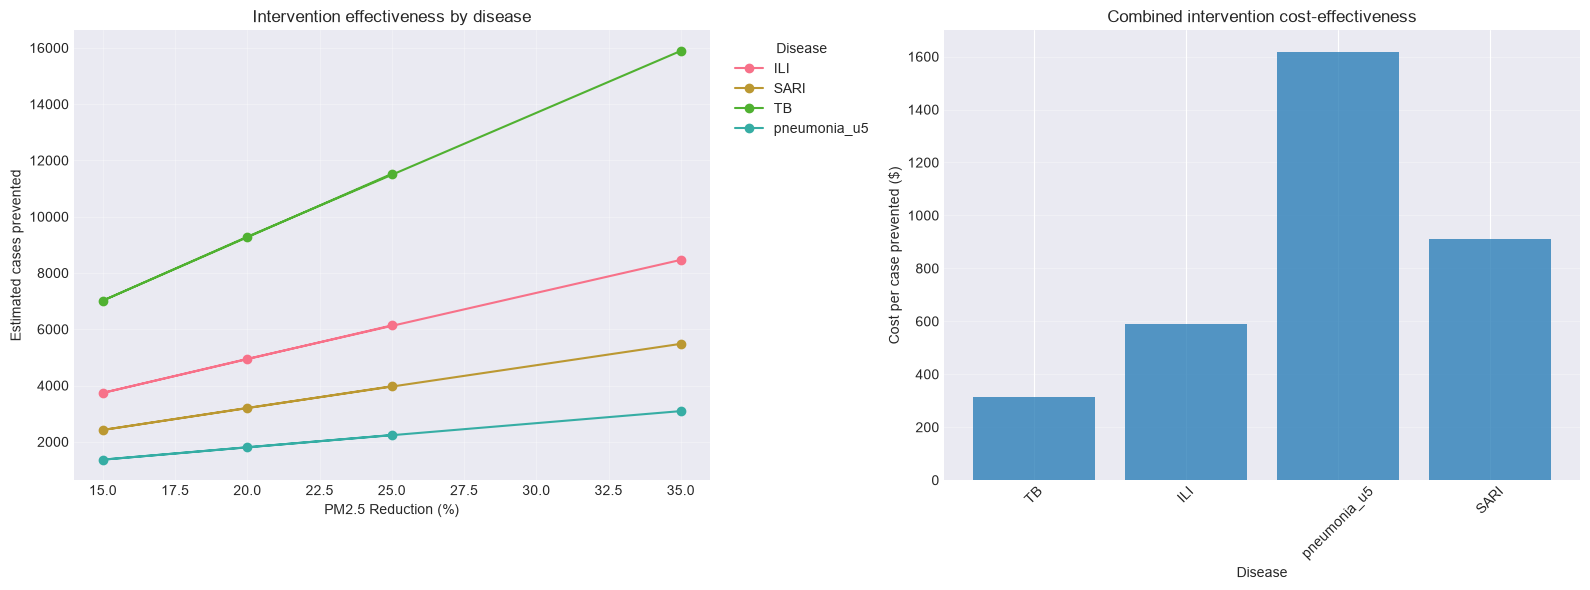

In [33]:
# Compare intervention effects across all diseases
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for disease, subset in results_df.groupby('Disease'):
    axes[0].plot(subset['PM2.5 Reduction (%)'], subset['Cases Prevented'], marker='o', label=disease)
axes[0].set(xlabel='PM2.5 Reduction (%)', ylabel='Estimated cases prevented', title='Intervention effectiveness by disease')
axes[0].legend(title='Disease', bbox_to_anchor=(1.02, 1), loc='upper left'); axes[0].grid(True, alpha=0.3)
combined = results_df[results_df['Scenario'].eq('Combined')]
axes[1].bar(combined['Disease'], combined['Cost per Case Prevented ($)'], color='tab:blue', alpha=0.75)
axes[1].set(xlabel='Disease', ylabel='Cost per case prevented ($)', title='Combined intervention cost-effectiveness')
axes[1].tick_params(axis='x', rotation=45); axes[1].grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## 8. Overall epidemiological interpretation and implications

Interpret the descriptive, regression, exposure–response, lag, climate, spatial/facility, and sensitivity outputs together. The results quantify patterns in routine surveillance data; they cannot by themselves establish that PM₂.₅ caused changes in disease notifications. Discuss effect sizes, uncertainty, data completeness, exposure measurement, reporting practices, residual confounding, and the consistency of findings across analyses before considering pollution-control or health-service implications.


### Reader-ready results summary

The following plain-language statements are templates filled with the estimates produced above. They are designed for quick reading and should be updated automatically whenever the notebook is re-run from top to bottom.


In [34]:
# Plain-language, automatically populated results statements for all diseases
print('READER-READY EPIDEMIOLOGICAL RESULTS SUMMARY'); print('=' * 72)
print(f"Observations: {len(processed_data):,}; period: {processed_data['date'].min():%d %b %Y} to {processed_data['date'].max():%d %b %Y}.")
print(f"Diseases analysed: {', '.join(disease_cols)}")
for title, table in [('Main regression estimates', regression_results), ('Exposure-response estimates', exposure_response_results), ('Distributed-lag cumulative estimates', dlnm_cumulative), ('Sensitivity estimates', sensitivity_results)]:
    print(f'\n{title}:'); display(table.round(3))
print('\nSpatial maps and tables report every diagnosis by Kampala division.')


READER-READY EPIDEMIOLOGICAL RESULTS SUMMARY
Observations: 248; period: 05 Jan 2020 to 15 Dec 2024.
Diseases analysed: TB, ILI, pneumonia_u5, SARI

Main regression estimates:


,Outcome,N,IRR per 10 µg/m³,95% CI lower,95% CI upper,p-value,AIC
0,TB,248,0.952,0.924,0.981,0.001,9616.184
1,ILI,248,1.173,1.030,1.335,0.016,85163.354
2,pneumonia_u5,248,0.956,0.908,1.005,0.080,7043.357
3,SARI,248,1.038,0.950,1.135,0.410,20987.404



Exposure-response estimates:


,Disease,Reference PM2.5,IRR per 10 µg/m³,95% CI lower,95% CI upper
0,TB,38.06,0.952,0.924,0.981
1,ILI,38.06,1.173,1.030,1.335
2,pneumonia_u5,38.06,0.956,0.908,1.005
3,SARI,38.06,1.038,0.950,1.135



Distributed-lag cumulative estimates:


,Disease,Lag window,Cumulative IRR per 10 µg/m³,95% CI lower,95% CI upper
0,TB,0–4,0.977,0.952,1.002
1,ILI,0–4,1.192,1.032,1.377
2,pneumonia_u5,0–4,0.969,0.903,1.039
3,SARI,0–4,1.043,0.951,1.144



Sensitivity estimates:


,Outcome,N,IRR per 10 µg/m³,95% CI lower,95% CI upper,p-value,AIC,Disease,Specification
0,TB,248,0.952,0.924,0.981,0.001,9616.184,TB,Primary adjusted model
1,TB,235,0.967,0.941,0.994,0.018,8175.979,TB,Exclude highest 5% PM2.5
2,TB,247,0.978,0.955,1.002,0.075,9334.700,TB,One-period lagged PM2.5
3,ILI,248,1.173,1.030,1.335,0.016,85163.354,ILI,Primary adjusted model
4,ILI,235,1.171,1.023,1.341,0.022,78738.665,ILI,Exclude highest 5% PM2.5
5,ILI,247,1.171,1.020,1.344,0.025,82541.138,ILI,One-period lagged PM2.5
6,pneumonia_u5,248,0.956,0.908,1.005,0.080,7043.357,pneumonia_u5,Primary adjusted model
7,pneumonia_u5,235,0.981,0.915,1.051,0.587,6672.798,pneumonia_u5,Exclude highest 5% PM2.5
8,pneumonia_u5,247,0.961,0.904,1.022,0.207,6977.398,pneumonia_u5,One-period lagged PM2.5
9,SARI,248,1.038,0.950,1.135,0.410,20987.404,SARI,Primary adjusted model



Spatial maps and tables report every diagnosis by Kampala division.


In [35]:
# Summary Report
print('=' * 72)
print('KAMPALA AIR QUALITY AND RESPIRATORY HEALTH ANALYSIS - SUMMARY REPORT')
print('=' * 72)
print(f"Analysis period: {summary['date_range']} | Records: {summary['total_records']}")
print(f"Average PM2.5: {summary['pm25_statistics']['mean']:.2f} μg/m³")
print(f"Diseases analysed: {', '.join(disease_cols)}")
print('\nDisease-model results:')
display(models_performance if 'models_performance' in globals() else lstm_performance)
print('\nIntervention results are reported for every disease and scenario:')
display(results_df.sort_values(['Disease', 'Cases Prevented'], ascending=[True, False]))
print('\nSpatial maps and tables report every recorded diagnosis by Kampala division.')


KAMPALA AIR QUALITY AND RESPIRATORY HEALTH ANALYSIS - SUMMARY REPORT
Analysis period: 2020-01-05 00:00:00 to 2024-12-15 00:00:00 | Records: 248
Average PM2.5: 39.28 μg/m³
Diseases analysed: TB, ILI, pneumonia_u5, SARI

Disease-model results:


,Disease,Model,MAE,RMSE,R²,Train Samples,Test Samples
0,pneumonia_u5,TensorFlow Fusion LSTM + Dense,126.353447,161.970168,-18.766612,188,48
1,TB,TensorFlow Fusion LSTM + Dense,277.991964,321.550949,-4.524185,188,48
2,SARI,TensorFlow Fusion LSTM + Dense,283.332630,356.099492,-5.258881,188,48
3,ILI,TensorFlow Fusion LSTM + Dense,1389.317985,1636.472705,-2.354510,188,48



Intervention results are reported for every disease and scenario:


,Disease,Scenario,PM2.5 Reduction (%),Final PM2.5 (μg/m³),Cases Prevented,Cost Factor,Cost per Case Prevented ($)
7,ILI,Combined,35.0,25.532052,8464.594286,5.0,590.695765
4,ILI,Traffic Control,25.0,29.460060,6136.819385,2.5,407.377151
6,ILI,Dust Control,20.0,31.424065,4946.275958,4.0,808.689211
5,ILI,Green Spaces,15.0,33.388069,3737.600566,3.0,802.653988
15,SARI,Combined,35.0,25.532052,5480.995218,5.0,912.243087
12,SARI,Traffic Control,25.0,29.460060,3973.714105,2.5,629.134340
14,SARI,Dust Control,20.0,31.424065,3202.813267,4.0,1248.902033
13,SARI,Green Spaces,15.0,33.388069,2420.171616,3.0,1239.581516
3,TB,Combined,35.0,25.532052,15892.262797,5.0,314.618507
0,TB,Traffic Control,25.0,29.460060,11521.868988,2.5,216.978687



Spatial maps and tables report every recorded diagnosis by Kampala division.


In [36]:
# Save downstream results
results_dir = Path('results')
results_dir.mkdir(parents=True, exist_ok=True)

notebook_tag = 'analysis'
results_df.to_csv(results_dir / f'{notebook_tag}_intervention_scenarios.csv', index=False)
models_performance.to_csv(results_dir / f'{notebook_tag}_model_performance.csv', index=False)

print(f"✓ Results saved to results/{notebook_tag}_intervention_scenarios.csv")
print(f"✓ Results saved to results/{notebook_tag}_model_performance.csv")


✓ Results saved to results/analysis_intervention_scenarios.csv
✓ Results saved to results/analysis_model_performance.csv
